# D03 · Bayesian data analysis, end to end: from exploratory plots to a report someone can act on

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | A gallery of eight cached datasets for the exploratory part, then the Palmer Station penguins (`penguins_raw`: 344 field records, body mass by species, sex and flipper length) as the running example |
| **You will learn** | EDA that *chooses the model* (support, mean-variance slope, group sizes, collinearity, residual structure) · priors from domain knowledge with **PreliZ** (`maxent`, `quartile`, `ppe`) · why many "weak" priors are one strong prior · reporting **estimands** instead of coefficients · probability statements and ROPE (`az.ci_in_rope`) · prior vs posterior · `az.bayesian_r2` / `az.loo_r2` · LOO-PIT calibration · power-scaling sensitivity (`az.psense_summary`) · likelihood sensitivity · `az.plot_khat` · a multiverse table · a written report generated from the fit |

E01 taught the loop *prior predictive -> fit -> diagnose -> posterior predictive*. That loop
is the easy part. This notebook is about the analysis **around** it:

| Part | Question it answers |
|---|---|
| 1 · EDA that chooses the model | What should I look at before writing `pm.Model()`, and what does each plot decide? |
| 2 · Priors from domain knowledge | How do I turn "adult penguins weigh 3-6 kg" into a distribution, and how do I test it? |
| 3 · Analysing a posterior | What do I report, on what scale, with which probability statements? |
| 4 · Robustness | Which conclusions survive another prior, another likelihood, another defensible choice? |
| 5 · The report | What does a non-statistician need to read, and what wording gets you into trouble? |

Part 1 needs no MCMC at all. Parts 2-4 fit one small regression several times (seconds each).

In [1]:
import logging
import sys
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
from IPython.display import Markdown
from scipy import stats

from pymc_challenges import data

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
warnings.filterwarnings("ignore", message=".*experimental.*")  # pz.ppe announces itself on every call
logging.getLogger("pymc").setLevel(logging.ERROR)  # ten fits below: keep the sampling log out of the page

print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PreliZ {pz.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, PreliZ 0.28.0


## Part 1 · EDA that chooses the model

Exploratory analysis for a Bayesian model is not a tour of every column. Each plot below is
there because it **decides something** about the model: the likelihood family, whether a
hierarchy will matter, whether coefficients will be identifiable, whether observations can
be treated as exchangeable. The habit to form: finish every EDA plot with the sentence
"so the model needs ...".

### 1.1 · The outcome's support and shape decide the likelihood

Six real outcomes, six different answers.

In [2]:
gallery = {}
for name in ["bike_day", "nsw", "trolley", "golf", "sp500", "radon"]:
    data.describe(name)
    gallery[name] = data.load(name)

bike_day: Daily rental counts 2011-2012 with weather and calendar covariates.
  source: Fanaee-T & Gama (2013), Capital Bikeshare (Washington DC), UCI ML Repository.
  url:    https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip
nsw: Randomised job-training experiment: 185 treated, 260 controls, earnings in 1978.
  source: LaLonde (1986) / Dehejia & Wahba (1999), National Supported Work experiment.
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/causaldata/nsw_mixtape.csv
trolley: 9930 ordinal (1-7) permissibility ratings from 331 participants.
  source: Cushman, Young & Hauser (2006) moral-judgement experiment, via `rethinking`.
  url:    https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Trolley.csv
golf: Putts attempted and made by distance (feet), 19 distances.
  source: Berry (1996), professional golf putting; used in Gelman & Nolan (2002).
  url:    https://raw.githubusercontent.com/stan-dev/example-models/master/knitr/golf/golf_dat

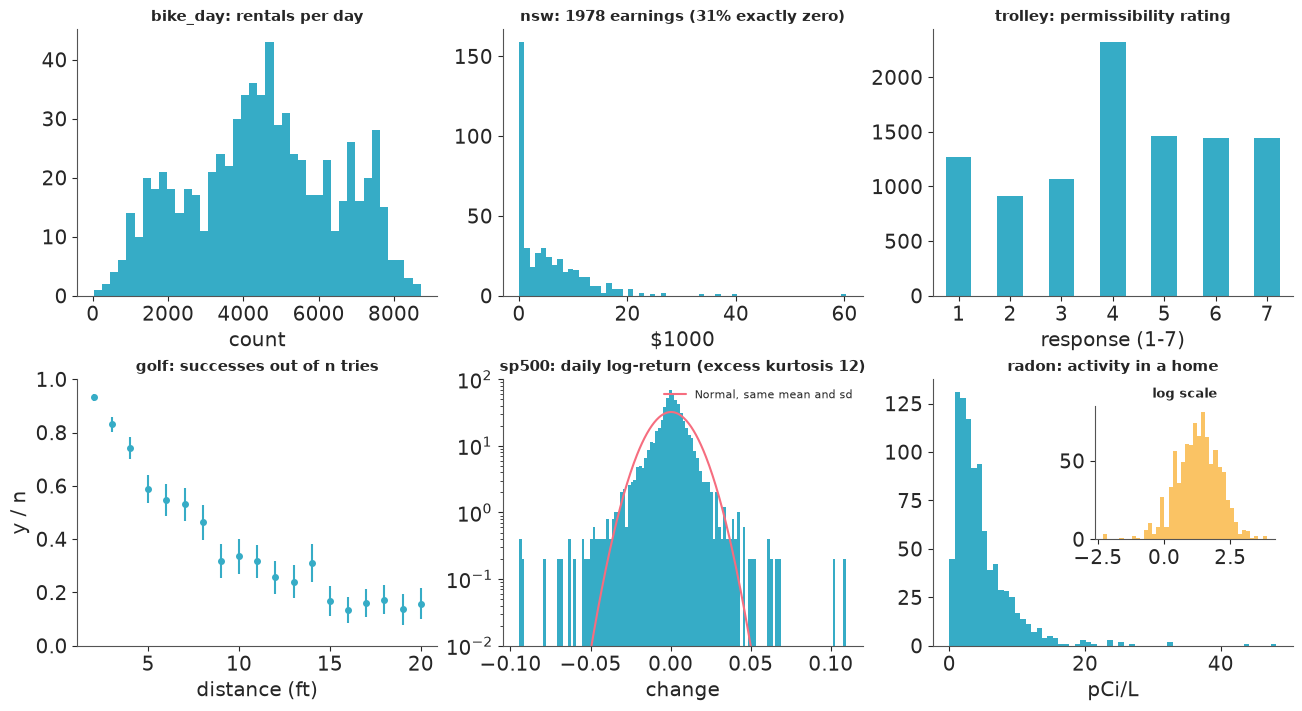

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

bike = gallery["bike_day"]
axes[0, 0].hist(bike.cnt, bins=40)
axes[0, 0].set(title="bike_day: rentals per day", xlabel="count")

nsw = gallery["nsw"]
axes[0, 1].hist(nsw.re78 / 1000, bins=60)
axes[0, 1].set(title=f"nsw: 1978 earnings ({(nsw.re78 == 0).mean():.0%} exactly zero)", xlabel="$1000")

trolley = gallery["trolley"]
trolley.response.value_counts().sort_index().plot.bar(ax=axes[0, 2], rot=0)
axes[0, 2].set(title="trolley: permissibility rating", xlabel="response (1-7)")

golf = gallery["golf"]
p_hat = golf.y / golf.n
axes[1, 0].errorbar(golf.x, p_hat, yerr=2 * np.sqrt(p_hat * (1 - p_hat) / golf.n), fmt="o", ms=4)
axes[1, 0].set(title="golf: successes out of n tries", xlabel="distance (ft)", ylabel="y / n", ylim=(0, 1))

ret = gallery["sp500"].change.dropna()
grid = np.linspace(ret.min(), ret.max(), 400)
axes[1, 1].hist(ret, bins=120, density=True)
axes[1, 1].plot(grid, stats.norm(ret.mean(), ret.std()).pdf(grid), color="C1", label="Normal, same mean and sd")
axes[1, 1].set(title=f"sp500: daily log-return (excess kurtosis {stats.kurtosis(ret):.0f})", yscale="log",
               ylim=(1e-2, 100), xlabel="change")
axes[1, 1].legend(fontsize=8)

radon = gallery["radon"]
axes[1, 2].hist(radon.activity, bins=60)
axes[1, 2].set(title="radon: activity in a home", xlabel="pCi/L")
ins = axes[1, 2].inset_axes([0.45, 0.4, 0.5, 0.5])
ins.hist(radon.log_radon, bins=40, color="C2")
ins.set_title("log scale", fontsize=9)
for ax in axes.ravel():
    ax.title.set_fontsize(11)

In [4]:
print(f"bike_day: min {bike.cnt.min()}, median {bike.cnt.median():.0f}, max {bike.cnt.max()}")
print(f"nsw:      {(nsw.re78 == 0).mean():.1%} zeros; among earners median ${nsw.re78[nsw.re78 > 0].median():,.0f}, "
      f"max ${nsw.re78.max():,.0f}")
print(f"sp500:    {(np.abs(ret - ret.mean()) > 4 * ret.std()).sum()} of {len(ret)} days beyond 4 sd; "
      f"a Normal expects {len(ret) * 2 * stats.norm.sf(4):.1f}")
print(f"radon:    skewness {stats.skew(radon.activity):.1f} raw, {stats.skew(radon.log_radon):.1f} after log")

bike_day: min 22, median 4548, max 8714
nsw:      30.8% zeros; among earners median $6,187, max $60,308
sp500:    23 of 2906 days beyond 4 sd; a Normal expects 0.2
radon:    skewness 3.4 raw, -0.3 after log


| What the plot shows | So the model needs | Modelled in |
|---|---|---|
| **bike_day** - counts, but in the thousands (one hurricane day aside). Discreteness is irrelevant; the *variance* is the question (next section) | a count or positive-continuous likelihood with a free dispersion, on a log link | C03 |
| **nsw** - a spike of exact zeros (unemployed all year) plus a long right tail | two processes: P(any earnings) and the amount if positive - a hurdle model. A Normal on dollars would put mass on negative earnings and let one man earning 60k drive the mean | C09 |
| **trolley** - seven ordered categories, piled up at 4 and at the ends | an ordered-categorical likelihood (cutpoints). Treating 1-7 as a number assumes equal spacing and predicts ratings of 7.6 | C05 |
| **golf** - y successes out of n, n varying from 1443 to under 200 | Binomial(n, p): the error bars already *are* the likelihood. Never model y/n with a Normal and throw n away | C01 |
| **sp500** - symmetric, but the log-scale histogram shows tails far above the Normal curve | a heavy-tailed likelihood (StudentT), and the tails cluster in time -> changing volatility | C07 |
| **radon** - positive, right-skewed; symmetric after a log | model log(y) with a Normal (= LogNormal): effects are multiplicative | E02 |

None of these decisions needed a model fit, and each of them matters more to the final
answer than any prior you will agonise over later.

### 1.2 · The mean-variance relationship picks the family

For counts and positive outcomes the support does not finish the job: Poisson,
NegativeBinomial, Gamma and LogNormal all live on the positive numbers. They differ in how
the **variance grows with the mean**, and that is something you can plot. Split the data
into groups that differ in their mean, compute each group's mean and variance, and look at
the slope on log-log axes:

| log-log slope | variance function | family |
|---|---|---|
| 1, *on* the line var = mean | var = mu | Poisson |
| 1, above the line | var = phi * mu | overdispersed Poisson ("NB1"): extra noise per event |
| 2 | var proportional to mu^2, constant coefficient of variation | NegativeBinomial at large mu (var = mu + mu^2/alpha), Gamma, LogNormal |
| 0 | var constant | Normal with additive errors |

Three datasets, three slopes:

epl_2425: All 380 match results with goals, shots and bookmaker odds.
  source: football-data.co.uk, English Premier League 2024/25.
  url:    https://www.football-data.co.uk/mmz4281/2425/E0.csv
bike_hour: Hourly rental counts 2011-2012 with weather and calendar covariates.
  source: Fanaee-T & Gama (2013), Capital Bikeshare (Washington DC), UCI ML Repository.
  url:    https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip
penguins_raw: 344 penguins as recorded in the field: messy column names, dates, comments, missing measurements.
  source: Gorman, Williams & Fraser (2014), Palmer Station LTER, via R `palmerpenguins` (raw field records).
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/palmerpenguins/penguins_raw.csv


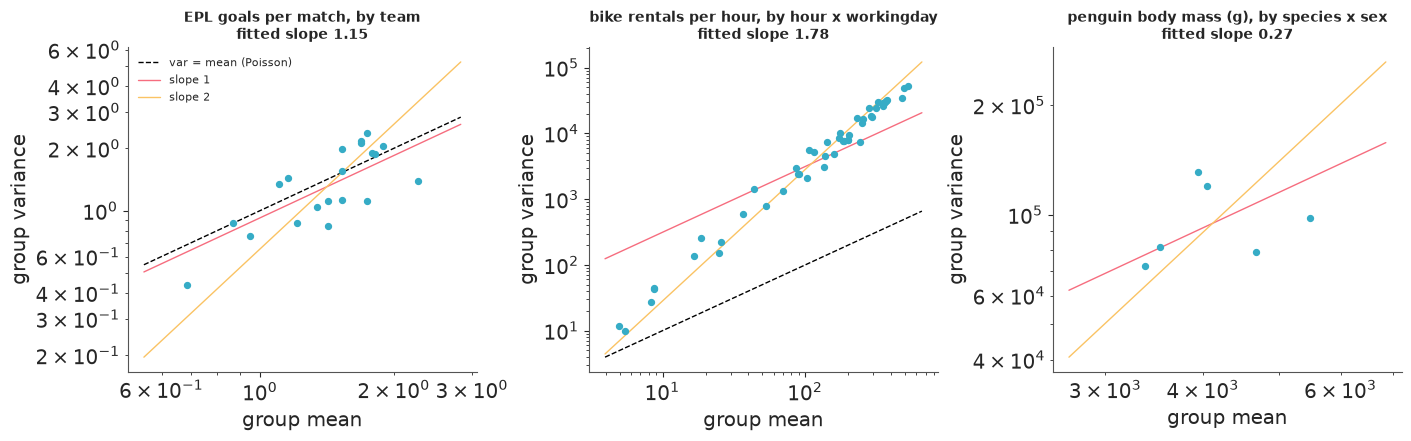

In [5]:
data.describe("epl_2425")
data.describe("bike_hour")
data.describe("penguins_raw")
epl, bike_hour, penguins_raw = data.load("epl_2425"), data.load("bike_hour"), data.load("penguins_raw")

goals = pd.concat([epl[["HomeTeam", "FTHG"]].set_axis(["team", "goals"], axis=1),
                   epl[["AwayTeam", "FTAG"]].set_axis(["team", "goals"], axis=1)])
peng_groups = penguins_raw.dropna(subset=["Sex", "Body Mass (g)"]).groupby(["Species", "Sex"])["Body Mass (g)"]

panels = {
    "EPL goals per match, by team": goals.groupby("team").goals,
    "bike rentals per hour, by hour x workingday": bike_hour.groupby(["hr", "workingday"]).cnt,
    "penguin body mass (g), by species x sex": peng_groups,
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
mv_slopes = {}
for ax, (title, grouped) in zip(axes, panels.items()):
    mv = grouped.agg(["mean", "var"])
    slope, intercept = np.polyfit(np.log(mv["mean"]), np.log(mv["var"]), 1)
    mv_slopes[title] = slope
    ax.scatter(mv["mean"], mv["var"], s=18, zorder=3)
    m = np.array([mv["mean"].min() * 0.8, mv["mean"].max() * 1.25])
    centre = np.exp(np.log(mv).mean())
    if "penguin" not in title:  # var = mean only means something for counts
        ax.plot(m, m, "k--", lw=1, label="var = mean (Poisson)")
    ax.plot(m, centre["var"] * (m / centre["mean"]), color="C1", lw=1, label="slope 1")
    ax.plot(m, centre["var"] * (m / centre["mean"]) ** 2, color="C2", lw=1, label="slope 2")
    ax.set(xscale="log", yscale="log", xlabel="group mean", ylabel="group variance",
           title=f"{title}\nfitted slope {slope:.2f}")
    ax.title.set_fontsize(10)
axes[0].legend(fontsize=8);

In [6]:
mv_goal = goals.groupby("team").goals.agg(["mean", "var"])
mv_bike = bike_hour.groupby(["hr", "workingday"]).cnt.agg(["mean", "var"])
mv_peng = peng_groups.agg(["mean", "std"])
print(f"EPL:      variance / mean per team: median {(mv_goal['var'] / mv_goal['mean']).median():.2f}")
print(f"bikes:    variance / mean per cell: median {(mv_bike['var'] / mv_bike['mean']).median():.0f};  "
      f"implied NegBinomial alpha = mu^2 / (var - mu): median {(mv_bike['mean']**2 / (mv_bike['var'] - mv_bike['mean'])).median():.1f}")
print(f"penguins: group sd from {mv_peng['std'].min():.0f} to {mv_peng['std'].max():.0f} g "
      f"while the mean goes from {mv_peng['mean'].min():.0f} to {mv_peng['mean'].max():.0f} g")

EPL:      variance / mean per team: median 1.01
bikes:    variance / mean per cell: median 41;  implied NegBinomial alpha = mu^2 / (var - mu): median 4.2
penguins: group sd from 269 to 362 g while the mean goes from 3369 to 5485 g


- **EPL goals**: the teams scatter around the dashed Poisson line (variance/mean close to 1).
  With 38 matches per team the scatter is wide, so the fitted slope itself means little -
  what matters is that nothing sits systematically above the line. *Decision: Poisson is a
  fine starting point* (C02).
- **Hourly bike rentals**: the quiet night-time cells sit just above the Poisson line, the
  busy ones two orders of magnitude above it, and the points follow the slope-2 line - the
  signature of var = mu + mu^2/alpha. A Poisson here would produce absurdly narrow
  predictive intervals. *Decision: NegativeBinomial (its `alpha` is roughly the number
  printed above) or a LogNormal/Gamma on the positive scale; the choice between those is
  about zeros and discreteness, not about fit.*
- **Penguin body mass** (not a count, so no Poisson line): the group means differ by 60% but
  the standard deviations barely move, and the slope is far below 2. *Decision: additive
  Normal errors on the gram scale; taking logs would impose a constant CV that these groups
  do not show.* We will still try the log model in Part 4 - as a sensitivity check, not as
  a belief - and see whether this forecast holds.

Caveat: the groups must differ in their mean for reasons *inside* the model. If a group
mixes regimes (say, sunny and rainy days), its variance includes between-regime variation
and the plot overstates dispersion. Group by the predictors you intend to use.

### 1.3 · Group sizes and between/within variation forecast how much pooling will matter

Before fitting a hierarchical model you can predict what it will do. With within-group
variance $\sigma^2$, between-group variance $\tau^2$ and group size $n_j$, the partial-pooling
estimate of group $j$ moves a fraction
$\lambda_j = \dfrac{\sigma^2/n_j}{\sigma^2/n_j + \tau^2}$
of the way from its raw mean towards the grand mean. A one-way ANOVA gives moment estimates
of both variances in three lines.

85 counties; homes per county: median 5, min 1, max 116
within-county sd 0.77, between-county sd 0.30, intraclass correlation 0.13
forecast pooling factor: median 0.57; 51 of 85 counties will sit closer to the state mean than to their own


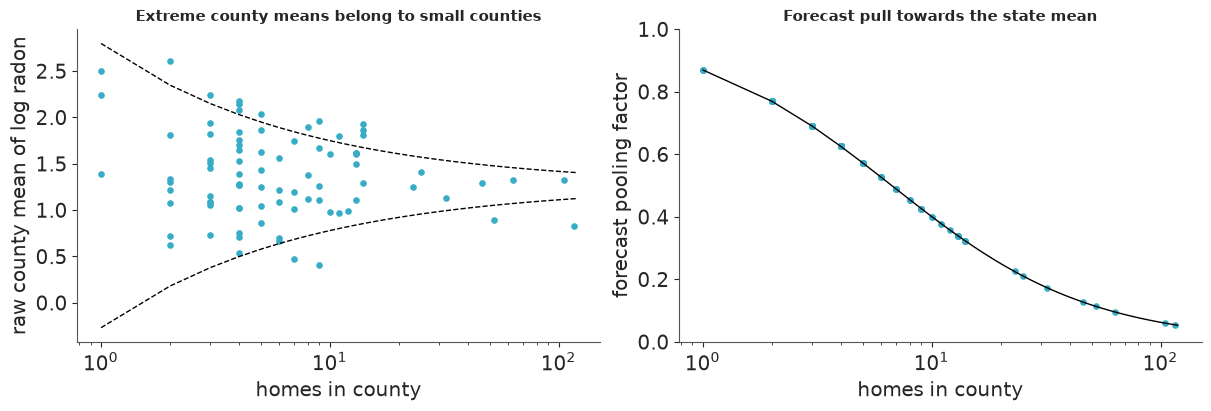

In [7]:
by_county = radon.groupby("county").log_radon.agg(["count", "mean"])
N, J = len(radon), len(by_county)
ms_within = ((radon.log_radon - radon.groupby("county").log_radon.transform("mean")) ** 2).sum() / (N - J)
ms_between = (by_county["count"] * (by_county["mean"] - radon.log_radon.mean()) ** 2).sum() / (J - 1)
n0 = (N - (by_county["count"] ** 2).sum() / N) / (J - 1)
tau2 = (ms_between - ms_within) / n0
by_county["pooling"] = (ms_within / by_county["count"]) / (ms_within / by_county["count"] + tau2)

print(f"{J} counties; homes per county: median {by_county['count'].median():.0f}, "
      f"min {by_county['count'].min()}, max {by_county['count'].max()}")
print(f"within-county sd {np.sqrt(ms_within):.2f}, between-county sd {np.sqrt(tau2):.2f}, "
      f"intraclass correlation {tau2 / (tau2 + ms_within):.2f}")
print(f"forecast pooling factor: median {by_county['pooling'].median():.2f}; "
      f"{(by_county['pooling'] > 0.5).sum()} of {J} counties will sit closer to the state mean than to their own")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
nn = np.arange(1, 120)
axes[0].scatter(by_county["count"], by_county["mean"], s=14)
for sign in (-1, 1):
    axes[0].plot(nn, radon.log_radon.mean() + sign * 2 * np.sqrt(ms_within / nn), "k--", lw=1)
axes[0].set(xscale="log", xlabel="homes in county", ylabel="raw county mean of log radon",
            title="Extreme county means belong to small counties")
axes[1].scatter(by_county["count"], by_county["pooling"], s=14)
axes[1].plot(nn, (ms_within / nn) / (ms_within / nn + tau2), "k-", lw=1)
axes[1].set(xscale="log", xlabel="homes in county", ylabel="forecast pooling factor",
            title="Forecast pull towards the state mean", ylim=(0, 1))
for ax in axes:
    ax.title.set_fontsize(11)

The dashed funnel is what pure sampling noise around the state mean would produce. The most
extreme raw means all belong to counties with fewer than ten homes, and the spread narrows
as counties grow, roughly as the funnel says it should; the points outside it are the
evidence that counties differ at all. The intraclass correlation is small, the typical county has five homes, and so the
forecast is that the **median county gets pulled more than half-way** to the state mean.

*Decision: a no-pooling model would mostly report noise for small counties and a complete-
pooling model would erase real differences for the big ones - this is a dataset where the
hierarchy changes the answers, and where the prior on $\tau$ deserves care. E02 fits it.*
Had the pooling factors all been below 0.05 (large groups, big between-group spread), a
hierarchical model would have returned the raw means and you could have saved the effort.

### 1.4 · Collinearity forecasts what the data cannot tell apart

Now the dataset for the rest of the notebook. The file is the raw field record; we do a
**minimal** clean here (rename, split the species label, drop incomplete rows) - **D01**
treats the cleaning of this file properly.

In [8]:
penguins_all = penguins_raw.rename(columns={
    "Body Mass (g)": "mass", "Flipper Length (mm)": "flipper",
    "Culmen Length (mm)": "bill_len", "Culmen Depth (mm)": "bill_dep", "Island": "island"})
penguins_all["species"] = penguins_all["Species"].str.split().str[0]
penguins_all["sex"] = penguins_all["Sex"].str.lower()
penguins_all["year"] = pd.to_datetime(penguins_all["Date Egg"]).dt.year

no_measure = penguins_all.mass.isna()
no_sex = penguins_all.sex.isna() & ~no_measure
penguins = penguins_all[~no_measure & ~no_sex].reset_index(drop=True)
print(f"{len(penguins_all)} records; {no_measure.sum()} without measurements, {no_sex.sum()} more without a sex "
      f"-> {len(penguins)} used")
print("unsexed birds by species:", penguins_all[no_sex].species.value_counts().to_dict())
print("comments on those rows:", list(penguins_all.loc[no_sex, "Comments"].dropna().str.slice(0, 36).unique()[:3]))
penguins.groupby(["species", "sex"]).agg(n=("mass", "size"), mass_mean=("mass", "mean"), mass_sd=("mass", "std"),
                                         flipper_mean=("flipper", "mean")).round(0)

344 records; 2 without measurements, 9 more without a sex -> 333 used
unsexed birds by species: {'Adelie': 5, 'Gentoo': 4}
comments on those rows: ['No blood sample obtained.', 'No blood sample obtained for sexing.', 'Sexing primers did not amplify. Not ']


n  mass_mean  mass_sd  flipper_mean
species   sex                                         
Adelie    female  73     3369.0    269.0         188.0
          male    73     4043.0    347.0         192.0
Chinstrap female  34     3527.0    285.0         192.0
          male    34     3939.0    362.0         200.0
Gentoo    female  58     4680.0    282.0         213.0
          male    61     5485.0    313.0         222.0

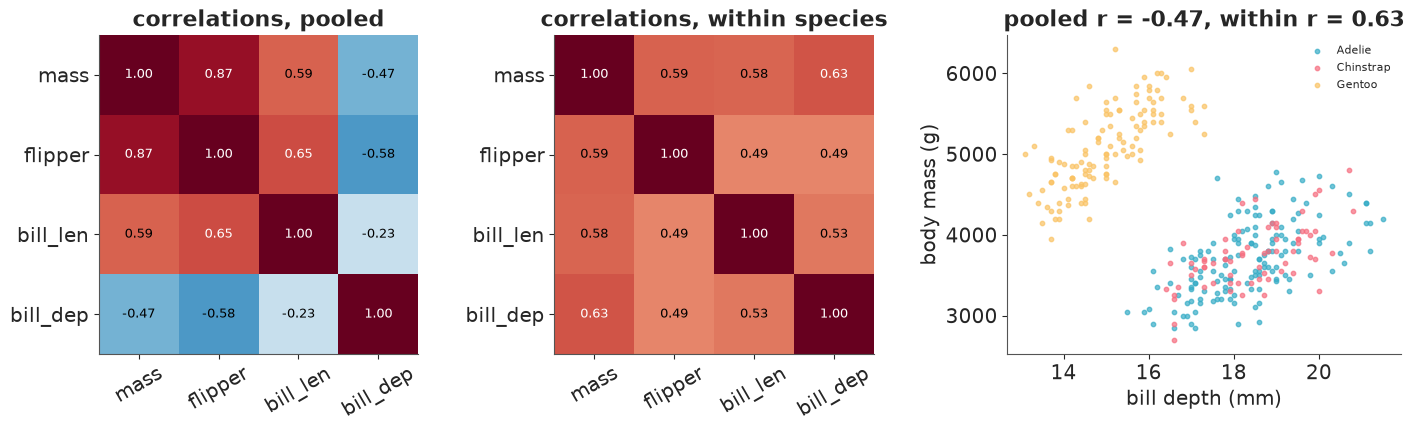

In [9]:
measures = ["mass", "flipper", "bill_len", "bill_dep"]
pooled_corr = penguins[measures].corr()
within_corr = penguins.groupby("species")[measures].transform(lambda s: s - s.mean()).corr()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, corr, title in zip(axes, [pooled_corr, within_corr], ["pooled", "within species"]):
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(4), measures, rotation=30)
    ax.set_yticks(range(4), measures)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9,
                    color="w" if abs(corr.iloc[i, j]) > 0.6 else "k")
    ax.set_title(f"correlations, {title}")
    ax.grid(False)
for sp, grp in penguins.groupby("species"):
    axes[2].scatter(grp.bill_dep, grp.mass, s=10, alpha=0.7, label=sp)
axes[2].set(xlabel="bill depth (mm)", ylabel="body mass (g)",
            title=f"pooled r = {pooled_corr.loc['mass', 'bill_dep']:.2f}, within r = {within_corr.loc['mass', 'bill_dep']:.2f}")
axes[2].legend(fontsize=8);

In [10]:
is_gentoo = (penguins.species == "Gentoo").astype(float)
print(f"correlation of flipper length with 'is a Gentoo': {np.corrcoef(penguins.flipper, is_gentoo)[0, 1]:.2f}")
print(f"share of flipper-length variance that lies between species x sex cells: "
      f"{1 - penguins.groupby(['species', 'sex']).flipper.transform(lambda s: s - s.mean()).var() / penguins.flipper.var():.2f}")

correlation of flipper length with 'is a Gentoo': 0.87
share of flipper-length variance that lies between species x sex cells: 0.84


Two forecasts from this picture:

1. **Sign flips.** Bill depth is *negatively* related to mass in the pooled data and
   *positively* within every species (Gentoos are heavy with shallow bills). Any model
   without species answers a different question from a model with it. Species goes in.
2. **A ridge in the posterior.** Flipper length is very nearly a species label: most of its
   variance lies between the species-by-sex cells. Once the cells have their own intercepts,
   only the remaining within-cell variation informs the flipper slope, and the slope will be
   negatively correlated with whichever intercepts belong to birds whose flippers are far
   from the centring point. *Decision: centre flipper length inside the data range, expect a
   wider slope posterior than the pooled scatter suggests, and do not interpret the species
   intercepts and the slope separately.* We check this forecast against the posterior in
   Part 3.

### 1.5 · Structure left in the residuals of a quick fit

Exchangeability is a modelling assumption you can test before you rely on it. Fit something
crude - least squares is fine, this is EDA - and look at the residuals along every axis the
model ignores: time, space, the order of data collection.

lag-1 autocorrelation 0.39; lags 2-14 average 0.08
crude effective sample size: 321 of 731 days
largest residual: 2012-10-29, 22 rentals (median day 4548)


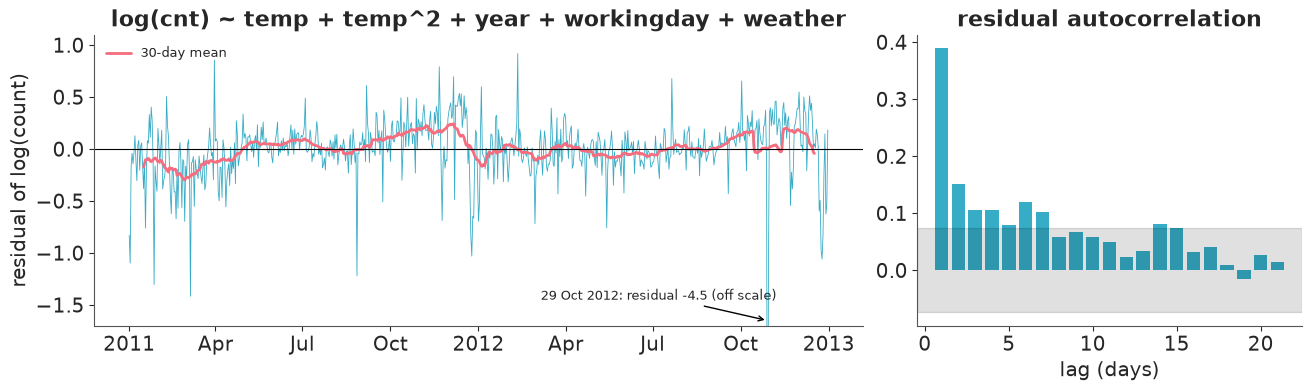

In [11]:
X_bike = np.column_stack([np.ones(len(bike)), bike.temp, bike.temp**2, bike.yr, bike.workingday,
                          bike.weathersit == 2, bike.weathersit == 3]).astype(float)
coef, *_ = np.linalg.lstsq(X_bike, np.log(bike.cnt), rcond=None)
resid = np.log(bike.cnt).values - X_bike @ coef
acf = np.array([np.corrcoef(resid[:-k], resid[k:])[0, 1] for k in range(1, 22)])

worst_day = int(np.argmin(resid))
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), width_ratios=[2, 1])
axes[0].plot(bike.dteday, resid, lw=0.6)
axes[0].plot(bike.dteday, pd.Series(resid).rolling(30, center=True).mean(), color="C1", lw=2, label="30-day mean")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set(ylabel="residual of log(count)", ylim=(-1.7, 1.1),
            title="log(cnt) ~ temp + temp^2 + year + workingday + weather")
axes[0].annotate(f"{bike.dteday[worst_day]:%d %b %Y}: residual {resid[worst_day]:.1f} (off scale)",
                 xy=(bike.dteday[worst_day], -1.65), xytext=(bike.dteday[430], -1.45), fontsize=9,
                 arrowprops={"arrowstyle": "->"})
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.ConciseDateFormatter(axes[0].xaxis.get_major_locator()))
axes[0].legend(loc="upper left", fontsize=9)
axes[1].bar(range(1, 22), acf)
axes[1].axhspan(-2 / np.sqrt(len(resid)), 2 / np.sqrt(len(resid)), color="k", alpha=0.12)
axes[1].set(xlabel="lag (days)", title="residual autocorrelation")
print(f"lag-1 autocorrelation {acf[0]:.2f}; lags 2-14 average {acf[1:14].mean():.2f}")
print(f"crude effective sample size: {len(resid) * (1 - acf[0]) / (1 + acf[0]):.0f} of {len(resid)} days")
print(f"largest residual: {bike.dteday[worst_day]:%Y-%m-%d}, {bike.cnt[worst_day]} rentals "
      f"(median day {bike.cnt.median():.0f})");

Two findings. The 30-day mean wanders (the quick model over-predicts the first winter and
under-predicts autumn 2011) and the autocorrelation is well outside the grey band for a
week, not just at lag 1. *Decision: a regression with independent errors would be
over-confident about every coefficient - by the crude AR(1) correction the data hold fewer
than half as many independent days as rows. The model needs a smooth time component (random
walk, spline or GP; see E05 and C03) or an autoregressive error.* And one day sits 4.5 log
units below the fit: 29 October 2012, when Hurricane Sandy shut Washington down. *Decision:
either an explicit indicator for known events or a likelihood with tails heavy enough not
to let one day move the weather coefficients.* The same plot against map coordinates does
the same job for spatial data (E07).

**Part 1 in one line:** support -> family; mean-variance slope -> dispersion; group sizes
and ICC -> whether to pool; collinearity -> what is identifiable; residual structure ->
what is exchangeable. All of it before any MCMC.

In [12]:
# Housekeeping: a notebook kernel keeps every variable alive to the end, and ten model fits are
# coming. Drop the gallery now; from here on only the penguins are needed.
del gallery, bike, bike_hour, nsw, trolley, golf, ret, radon, epl, goals, by_county, X_bike, resid

## Part 2 · Turning domain knowledge into priors with PreliZ

### The brief

The Palmer Station field team weighs birds to monitor **body condition**. To say a bird is
light they need a reference: the expected mass of a healthy bird of the same species and the
same structural size (flipper length). Their question for us:

> *Does the reference also have to depend on **sex**? Sexing a penguin needs a blood sample
> and a lab (it could not be done for nine of the birds measured here). If a male and a female of the
> same species and flipper length differ by less than about **200 g** - roughly 5% of a
> bird, the size of change we would act on - one reference line per species is enough.*

That fixes the **estimand** before any modelling: the male-minus-female difference in
expected body mass *at equal species and flipper length*, in grams, per species, judged
against 200 g. Note what it is not: it is not "how much heavier are males" (the raw
difference, which includes males simply being bigger birds - 675 g vs 412 g vs 805 g in the
table above). Those are different questions with different answers, and only the brief can
say which one is wanted.

$$
\begin{aligned}
\text{mass}_i &\sim \text{Normal}(\mu_i, \sigma) \\
\mu_i &= a_{s[i]} + d_{s[i]}\,\text{male}_i + b\,(\text{flipper}_i - 200)
\end{aligned}
$$

$a_s$ is the expected mass of a female of species $s$ with a 200 mm flipper, $d_s$ the sex
difference we were asked about, $b$ grams per millimetre of flipper. Normal errors and an
additive structure are what section 1.2 suggested; the per-species $d_s$ is there because the
question is per species.

### 2.1 · Priors from constraints

Nobody knows a prior standard deviation. People know **ranges**. `pz.maxent` finds the
maximum-entropy member of a family with a stated mass between two bounds - the least
informative distribution that still honours what you said. `pz.quartile` does the same from
three quartiles. Here is the knowledge, stated before looking at the body-mass column:

- Adult *Pygoscelis* penguins weigh between about 2.7 kg (a small Adelie) and 6.3 kg (a big
  Gentoo): 95% of the mass for each $a_s$ in that range.
- Males are heavier in most penguins, by up to 10-20%, but we do not want the prior to
  decide the sign: $d_s$ centred on 0 with 95% of its mass within +-1000 g.
- Geometry bounds the slope. If a bird scaled up perfectly (mass proportional to
  length cubed), one more millimetre on a 200 mm, 4.2 kg bird would add 3 x 4200/200 = 63 g.
  Within a species, a longer flipper is a much weaker signal of overall size than that, and
  it will not be negative: 95% of $b$ between 0 and 65 g/mm.
- Birds of the same kind differ "by a few hundred grams": quartiles of $\sigma$ at 200, 300
  and 450 g.

/var/folders/nw/92nd031j7p5d2bs8grpysp4w0000gn/T/ipykernel_12898/3016398763.py:6: UserWarning: 
The expected masses are 0.25, 0.5, 0.75
The computed ones are: 0.26, 0.49, 0.76
  prior_sigma, _ = pz.quartile(pz.Gamma(), 200, 300, 450, plot_kwargs={"ax": axes[3], "legend": None})


    a: Normal(mu=4.5e+03, sigma=918)   ->  Normal(mean=4500.0, median=4500.0, std=918.38, lower=2700.0, upper=6300.0)
    d: Normal(mu=0, sigma=510)   ->  Normal(mean=0.0, median=0.0, std=510.21, lower=-1000.0, upper=1000.0)
    b: Normal(mu=32.5, sigma=16.6)   ->  Normal(mean=32.5, median=32.5, std=16.58, lower=0.0, upper=65.0)
sigma: Gamma(alpha=3.03, beta=0.00888)   ->  Gamma(mean=341.26, median=304.54, std=196.06, lower=71.13, upper=819.09)


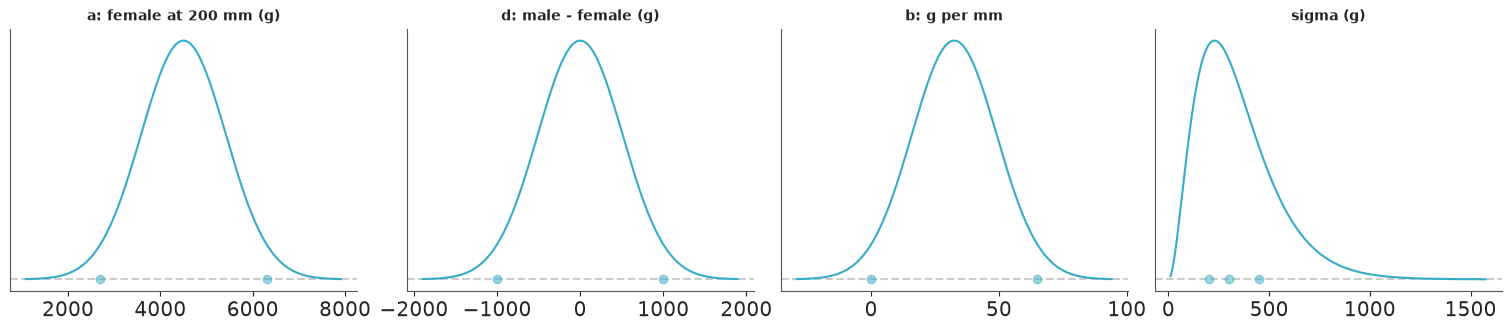

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
# maxent silently ignores ax= in PreliZ 0.28 (everything lands on the last axes): go through plot_kwargs
prior_a, _ = pz.maxent(pz.Normal(), 2700, 6300, 0.95, plot_kwargs={"ax": axes[0], "legend": None})
prior_d, _ = pz.maxent(pz.Normal(mu=0), -1000, 1000, 0.95, plot_kwargs={"ax": axes[1], "legend": None})
prior_b, _ = pz.maxent(pz.Normal(), 0, 65, 0.95, plot_kwargs={"ax": axes[2], "legend": None})
prior_sigma, _ = pz.quartile(pz.Gamma(), 200, 300, 450, plot_kwargs={"ax": axes[3], "legend": None})
for ax, title in zip(axes, ["a: female at 200 mm (g)", "d: male - female (g)", "b: g per mm", "sigma (g)"]):
    ax.set_title(title, fontsize=10)

for name, dist in [("a", prior_a), ("d", prior_d), ("b", prior_b), ("sigma", prior_sigma)]:
    print(f"{name:>5}: {dist}   ->  {dist.summary(mass=0.95)}")

The dots mark the numbers we stated; the curve is what PreliZ made of them. Things to know
about these helpers (PreliZ 0.28): they return a tuple `(distribution, axes)` - but only
the distribution when called with `plot=False`; a parameter given in the constructor
(`pz.Normal(mu=0)`) is held fixed and the rest are solved for; `quartile` warns when the
family cannot hit all three numbers exactly - the Gamma above is a near miss (26/49/76%
instead of 25/50/75%), which is fine for a prior. `dist.summary()`, `dist.plot_pdf()` and
`dist.to_pymc("name")` do what they say.

### 2.2 · Priors stated on the outcome scale - and a tool to triple-check

Experts find it easier still to describe **observable quantities** ("what would a bird
weigh?") than parameters. PreliZ has an experimental helper for that direction, `pz.ppe`
(prior predictive elicitation): give it a PyMC model and a target distribution for the
*outcome*, and it returns model code whose priors make the prior predictive match the
target. Try it on the simplest possible model, with two different numbers of observations:

In [14]:
target = pz.maxent(pz.Normal(), 2700, 6300, 0.95, plot=False)
print("target for the mass of one bird:", target, "\n")
for n_obs in (10, 1000):
    with pm.Model() as toy:
        pm.Normal("y", pm.Normal("a", 0, 10_000), pm.HalfNormal("s", 10_000), observed=np.zeros(n_obs))
    print(f"--- model with {n_obs} observations\n{pz.ppe(toy, target)}")

target for the mass of one bird: Normal(mu=4.5e+03, sigma=918) 



--- model with 10 observations
with pm.Model() as model:
    a = pm.Normal("a", mu=4.52e+03, sigma=288)
    s = pm.HalfNormal("s", sigma=867)

--- model with 1000 observations
with pm.Model() as model:
    a = pm.Normal("a", mu=4.5e+03, sigma=28.2)
    s = pm.HalfNormal("s", sigma=917)



The prior predictive *does* match the target - centre 4500 g, spread about 900 g, all of it
assigned to `s`. But look at the prior on `a`: its width shrinks with the number of
observations in the model (about $918/\sqrt{n}$). `ppe` draws datasets from the target, fits
each by maximum likelihood and fits a prior to those estimates - so the prior on the mean
encodes *sampling noise of an n-bird average*, not what we know about the mean. With 1000
rows it claims we know the species mean to +-30 g before seeing data. The function's own
warning says "triple-check the results"; this is what that looks like. **A statement about
individual birds does not pin down a prior on a mean** - you need a second statement ("the
typical bird of a species could be anywhere from 2.7 to 6.3 kg"), which is exactly what we
gave `maxent` above. We keep the 2.1 priors.

### 2.3 · Many "weak" priors are one strong prior

The most common prior mistake in applied regression is invisible on any single coefficient.
Standardise everything, put an innocent-looking `Normal(0, 1)` (or a "vague"
`Normal(0, 10)`) on each of $p$ coefficients, and ask what that implies for a quantity you
have an opinion about: the **share of variance explained**, or a **predicted probability**.
We use the real penguin design matrix - species, sex, their interaction, three body
measurements, island and year: 12 columns - once for a regression on standardised body mass
and once for a logistic regression of sex.

Normal(0, 10)  'vague'               P(R2 > 0.9) = 1.00   median R2 = 1.00   P(predicted probability outside 0.01-0.99) = 0.87
Normal(0, 1)  'weakly informative'   P(R2 > 0.9) = 0.65   median R2 = 0.95   P(predicted probability outside 0.01-0.99) = 0.13
Normal(0, 1/sqrt(p)), p = 12         P(R2 > 0.9) = 0.27   median R2 = 0.64   P(predicted probability outside 0.01-0.99) = 0.00


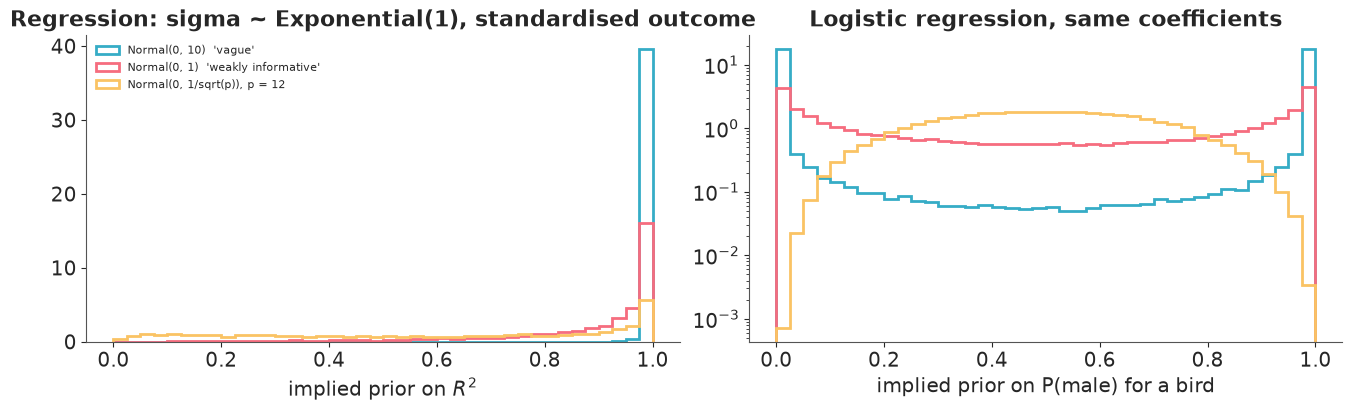

In [15]:
design = pd.get_dummies(penguins[["species", "island", "year"]].astype(str), drop_first=True).astype(float)
design["male"] = (penguins.sex == "male").astype(float)
for sp in ["Chinstrap", "Gentoo"]:
    design[f"male:{sp}"] = design["male"] * design[f"species_{sp}"]
design[["flipper", "bill_len", "bill_dep"]] = penguins[["flipper", "bill_len", "bill_dep"]]
Z = ((design - design.mean()) / design.std()).values
Z_no_sex = Z[:, [i for i, c in enumerate(design.columns) if "male" not in c]]
p = Z.shape[1]

prior_sets = {"Normal(0, 10)  'vague'": 10.0, "Normal(0, 1)  'weakly informative'": 1.0,
              f"Normal(0, 1/sqrt(p)), p = {p}": 1 / np.sqrt(p)}
n_sim = 4000
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, scale in prior_sets.items():
    beta = rng.normal(0, scale, size=(n_sim, p))
    sigma = rng.exponential(1.0, size=n_sim)
    var_fit = (Z @ beta.T).var(axis=0)
    r2 = var_fit / (var_fit + sigma**2)
    prob = 1 / (1 + np.exp(-(Z_no_sex @ beta[:500, : Z_no_sex.shape[1]].T)))
    axes[0].hist(r2, bins=40, range=(0, 1), histtype="step", lw=2, density=True, label=label)
    axes[1].hist(prob.ravel(), bins=40, range=(0, 1), histtype="step", lw=2, density=True, label=label)
    print(f"{label:<36} P(R2 > 0.9) = {(r2 > 0.9).mean():.2f}   median R2 = {np.median(r2):.2f}   "
          f"P(predicted probability outside 0.01-0.99) = {((prob < 0.01) | (prob > 0.99)).mean():.2f}")
axes[0].set(xlabel="implied prior on $R^2$", title="Regression: sigma ~ Exponential(1), standardised outcome")
axes[1].set(xlabel="implied prior on P(male) for a bird", title="Logistic regression, same coefficients", yscale="log")
axes[0].legend(fontsize=8);

With twelve independent `Normal(0, 1)` coefficients the prior's median $R^2$ is 0.95; with
`Normal(0, 10)` it is *certain* the model explains everything, and as a classifier it
believes that for nearly nine birds in ten the sex is known in advance with 99% confidence
(note the log axis on the right: the end bins hold almost all the mass). No one holds
those beliefs. They are an accident of stating priors one coefficient at a time: the
variance of the linear predictor is the **sum** over coefficients, so it grows with $p$
unless the scales shrink like $1/\sqrt{p}$ (third curve), or unless you put the prior on
$R^2$ itself and divide it among the coefficients (the R2D2 family of priors does that).
Whether this matters depends on how much data you have - with 333 birds and 12 columns it
would wash out; with 40 birds it would not - and **prior predictive simulation is the only
way to see it**, because every marginal prior looks harmless.

### 2.4 · The prior predictive check is the test

Now the running model. It is a function because Part 4 will refit it under other defensible
choices; the arguments are those choices. `expected` is the expected mass on the **gram
scale**, whatever the likelihood - which is what makes the estimand code in Part 3 reusable.

In [16]:
sp_idx, species = pd.factorize(penguins.species, sort=True)
year_idx, years = pd.factorize(penguins.year, sort=True)
is_male = (penguins.sex == "male").astype(int).values
FLIPPER_REF = 200.0


def build_model(likelihood="normal", prior_scale=1.0, d_sigma=None, sigma_by_sex=False, year_effect=False,
                use_flipper=True):
    coords = {"species": species, "sex": ["female", "male"], "year": years, "obs": penguins.index}
    with pm.Model(coords=coords) as model:
        sp = pm.Data("sp", sp_idx, dims="obs")
        male = pm.Data("male", is_male, dims="obs")
        flipper_c = pm.Data("flipper_c", penguins.flipper.values - FLIPPER_REF, dims="obs")
        yr = pm.Data("yr", year_idx, dims="obs")

        log_scale = likelihood == "lognormal"
        if log_scale:  # same knowledge, restated as proportions of a 4.5 kg bird
            a = pm.Normal("a", np.log(4500), 0.2 * prior_scale, dims="species")
            d = pm.Normal("d", 0, d_sigma or 0.12 * prior_scale, dims="species")
            b = pm.Normal("b", 0.0075, 0.004 * prior_scale)
            sigma_shape = {"dims": "sex"} if sigma_by_sex else {}
            sigma = pm.Gamma("sigma", mu=0.08, sigma=0.05 * prior_scale, **sigma_shape)
        else:
            a = pm.Normal("a", prior_a.mu, prior_a.sigma * prior_scale, dims="species")
            d = pm.Normal("d", 0, d_sigma or prior_d.sigma * prior_scale, dims="species")
            b = pm.Normal("b", prior_b.mu, prior_b.sigma * prior_scale)
            sigma_shape = {"dims": "sex"} if sigma_by_sex else {}
            sigma = pm.Gamma("sigma", mu=prior_sigma.mean(), sigma=prior_sigma.std() * prior_scale, **sigma_shape)

        mu = a[sp] + d[sp] * male
        if use_flipper:
            mu = mu + b * flipper_c
        if year_effect:
            season_sd = pm.HalfNormal("season_sd", 0.05 if log_scale else 200)
            mu = mu + pm.ZeroSumNormal("season", season_sd, dims="year")[yr]
        s = sigma[male] if sigma_by_sex else sigma

        if log_scale:
            pm.Deterministic("expected", pm.math.exp(mu + s**2 / 2), dims="obs")
            pm.LogNormal("mass", mu, s, observed=penguins.mass.values, dims="obs", shape=mu.shape)
        else:
            pm.Deterministic("expected", mu, dims="obs")
            if likelihood == "normal":
                pm.Normal("mass", mu, s, observed=penguins.mass.values, dims="obs", shape=mu.shape)
            else:
                nu = pm.Gamma("nu", 2, 0.1)
                pm.StudentT("mass", nu=nu, mu=mu, sigma=s, observed=penguins.mass.values, dims="obs", shape=mu.shape)
    return model


model = build_model()
vague_model = build_model(prior_scale=20.0)  # what "let the data speak" looks like
with model:
    idata = pm.sample_prior_predictive(1000, random_seed=RANDOM_SEED)
with vague_model:
    idata_vague_prior = pm.sample_prior_predictive(1000, random_seed=RANDOM_SEED)
model

elicited   simulated birds outside 1-10 kg: 0.1%   negative: 0.0%   implied R2: median 0.88, 90% interval [0.42 0.99]
x20 wider  simulated birds outside 1-10 kg: 81.8%   negative: 41.0%   implied R2: median 1.00, 90% interval [1. 1.]


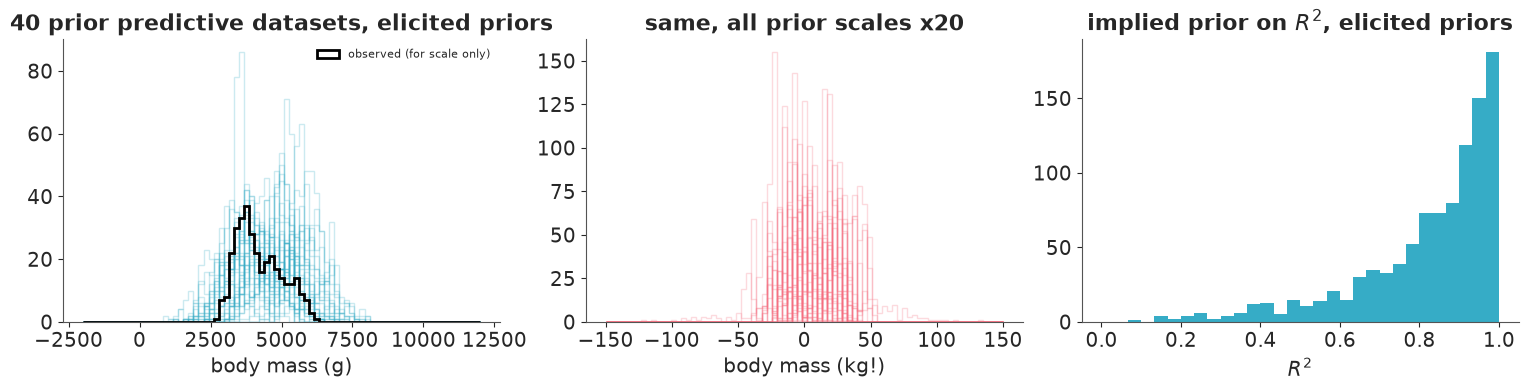

In [17]:
def prior_report(tree, label):
    mass_sim = tree.prior_predictive["mass"]
    expected = tree.prior["expected"]
    r2 = expected.var("obs") / (expected.var("obs") + tree.prior["sigma"] ** 2)
    print(f"{label:<10} simulated birds outside 1-10 kg: {float(((mass_sim < 1000) | (mass_sim > 10_000)).mean()):.1%}   "
          f"negative: {float((mass_sim < 0).mean()):.1%}   implied R2: median {float(r2.median()):.2f}, "
          f"90% interval {np.round(r2.quantile([0.05, 0.95]).values, 2)}")
    return r2


r2_prior = prior_report(idata, "elicited")
_ = prior_report(idata_vague_prior, "x20 wider")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
bins = np.linspace(-2000, 12000, 80)
for k in range(40):
    axes[0].hist(idata.prior_predictive["mass"].isel(chain=0, draw=k), bins=bins, histtype="step", color="C0", alpha=0.25)
axes[0].hist(penguins.mass, bins=bins, histtype="step", color="k", lw=2, label="observed (for scale only)")
axes[0].set(title="40 prior predictive datasets, elicited priors", xlabel="body mass (g)")
axes[0].legend(fontsize=8)
for k in range(40):
    axes[1].hist(idata_vague_prior.prior_predictive["mass"].isel(chain=0, draw=k) / 1000, bins=np.linspace(-150, 150, 80),
                 histtype="step", color="C1", alpha=0.25)
axes[1].set(title="same, all prior scales x20", xlabel="body mass (kg!)")
axes[2].hist(r2_prior.values.ravel(), bins=30, range=(0, 1))
axes[2].set(title="implied prior on $R^2$, elicited priors", xlabel="$R^2$")
del idata_vague_prior, vague_model  # only needed for this picture

The elicited priors generate penguin-sized penguins: datasets spread between roughly 2 and
8 kg, practically no simulated bird outside 1-10 kg, and the observed histogram is one
unremarkable member of the family. The "x20" version produces birds of minus 50 kg. It would
give nearly the same posterior here (333 birds swamp it), but it is not a statement of
ignorance - it is a statement that four penguins in five weigh less than 1 kg or more than
10 kg, and it would hurt as soon as a cell had three birds in it.

The implied $R^2$ deserves an honest look, given section 2.3: it leans towards 1 (median
near 0.9) with a long left tail. Here that is not an accident of counting coefficients but
a belief we can state and defend: the three intercepts are allowed to differ by a kilogram
or more while birds of one kind differ by a few hundred grams, so *of course* species, sex
and size are expected to explain most of the variance in a mixed sample. The "x20" prior is
*certain* of $R^2 = 1$, which nobody believes. If the elicited lean were not defensible, the
fix would be a hierarchical prior on the intercepts, not wider marginals.

## Part 3 · Analysing a posterior properly

### 3.1 · Fit, and one paragraph of diagnostics

E01 covers convergence diagnostics; in a report they deserve one sentence, so we compute
the ingredients of that sentence. We also store the pointwise log-likelihood and the
**log-prior** - Part 4's sensitivity analysis needs both
(`pm.compute_log_likelihood`, `pm.stats.compute_log_prior`).

In [18]:
def fit(model, predictive=False, log_prior=False):
    """Sample; add only the groups the caller will use (every group is 4000 x 333 numbers)."""
    with model:
        tree = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
        pm.compute_log_likelihood(tree, progressbar=False)  # LOO, power-scaling
        if predictive:
            pm.sample_posterior_predictive(tree, extend_inferencedata=True, random_seed=RANDOM_SEED, progressbar=False)
        if log_prior:
            pm.stats.compute_log_prior(tree, progressbar=False)  # power-scaling
    return tree


idata.update(fit(model, predictive=True, log_prior=True))
params = ["a", "d", "b", "sigma"]
summ = az.summary(idata, var_names=params, ci_kind="hdi", ci_prob=0.94, round_to=1)
diag = {"rhat": float(summ.r_hat.max()), "ess": int(min(summ.ess_bulk.min(), summ.ess_tail.min())),
        "div": int(idata.sample_stats["diverging"].sum()), "chains": idata.posterior.sizes["chain"],
        "draws": idata.posterior.sizes["draw"], "tune": int(idata.posterior.attrs["tuning_steps"])}
print(diag)
summ

{'rhat': 1.0, 'ess': 1475, 'div': 0, 'chains': 4, 'draws': 1000, 'tune': 400}


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a[Adelie],3631.6,47.4,3544.1,3719.2,1632.5,2171.5,1.0,1.2,0.7
a[Chinstrap],3708.8,54.8,3602.4,3807.0,2014.3,2305.0,1.0,1.2,0.9
a[Gentoo],4414.1,50.3,4321.5,4509.2,1928.9,2216.8,1.0,1.1,0.7
d[Adelie],570.4,48.6,479.0,662.2,2849.6,2822.8,1.0,0.9,0.7
d[Chinstrap],228.6,75.4,83.6,365.9,2279.2,2580.4,1.0,1.6,1.2
d[Gentoo],609.6,59.5,498.6,719.2,2564.0,2737.6,1.0,1.2,1.0
b,21.3,2.8,16.2,26.5,1475.7,1988.6,1.0,0.1,0.0
sigma,288.2,11.2,267.4,308.6,5599.4,3187.7,1.0,0.2,0.2


Clean. (One thing to get right in the write-up: with nutpie, `pm.sample()` in PyMC 6.3 warms
up for **400** steps, not the 1000 of older versions - the sampler records what it did in
`idata.posterior.attrs`, so quote that rather than your memory of the defaults.)

Before interpreting anything, check the forecast from section 1.4 - that flipper
length and the group intercepts would be hard to separate:

In [19]:
post = az.extract(idata, var_names=params)
for sp in species:
    print(f"corr(b, a[{sp}]) = {np.corrcoef(post['b'], post['a'].sel(species=sp))[0, 1]:+.2f}    "
          f"corr(b, d[{sp}]) = {np.corrcoef(post['b'], post['d'].sel(species=sp))[0, 1]:+.2f}")
pooled_slope = np.polyfit(penguins.flipper, penguins.mass, 1)[0]
print(f"\npooled least-squares slope {pooled_slope:.0f} g/mm;  posterior for b: {float(post['b'].mean()):.0f} "
      f"+- {float(post['b'].std()):.1f} g/mm")

corr(b, a[Adelie]) = +0.70    corr(b, d[Adelie]) = -0.25
corr(b, a[Chinstrap]) = +0.42    corr(b, d[Chinstrap]) = -0.32
corr(b, a[Gentoo]) = -0.66    corr(b, d[Gentoo]) = -0.46

pooled least-squares slope 50 g/mm;  posterior for b: 21 +- 2.8 g/mm


As forecast: the slope is strongly correlated with the intercepts of the birds whose
flippers are far from 200 mm (negatively with Gentoo, positively with Adelie) and
negatively with every sex difference - some of the male-female gap can be re-labelled as
"males have longer flippers" and the data only partly resolve which. The within-group slope
is less than half the pooled one. This is why the table above is **not** the result: the
coefficients are entangled, their meaning depends on the centring point, and none of them
is on its own the answer to the brief.

### 3.2 · Report estimands, not coefficients

The recipe that works for *any* model: set the inputs to the scenarios you were asked
about, push the posterior draws through, and summarise differences **per draw**. Here the
scenario pair is "every bird as a male" versus "the same bird as a female", keeping species
and flipper length as observed - an *average predictive comparison*.

In [20]:
def expected_mass(model, tree, **new_data):
    """Posterior draws of the expected mass (g) for every bird, with some inputs replaced."""
    original = {k: model[k].get_value() for k in new_data}
    with model:
        pm.set_data(new_data)
        out = pm.sample_posterior_predictive(tree, var_names=["expected"], predictions=True,
                                             random_seed=RANDOM_SEED, progressbar=False).predictions["expected"]
        pm.set_data(original)
    return out.assign_coords(species=("obs", penguins.species.to_numpy(dtype=object)))


def sex_difference(model, tree):
    n = len(penguins)
    per_bird = expected_mass(model, tree, male=np.ones(n, dtype=int)) - expected_mass(model, tree, male=np.zeros(n, dtype=int))
    return per_bird.groupby("species").mean().rename("sex_difference")


THRESHOLD = 200.0
sex_diff = sex_difference(model, idata)


def describe_draws(x, prob=0.94):
    lo, hi = az.hdi(x, prob=prob).values
    return {"mean": float(x.mean()), "sd": float(x.std()), "lo": float(lo), "hi": float(hi)}


estimands = pd.DataFrame({sp: describe_draws(sex_diff.sel(species=sp)) for sp in species}).T
estimands[f"P(> {THRESHOLD:.0f} g)"] = [(float((sex_diff.sel(species=sp) > THRESHOLD).mean())) for sp in species]
estimands["raw difference"] = penguins.groupby(["species", "sex"]).mass.mean().unstack().pipe(lambda t: t.male - t.female)
estimands.round({"mean": 0, "sd": 0, "lo": 0, "hi": 0, f"P(> {THRESHOLD:.0f} g)": 3, "raw difference": 0})

,mean,sd,lo,hi,P(> 200 g),raw difference
Adelie,570.0,49.0,479.0,662.0,1.000,675.0
Chinstrap,229.0,75.0,84.0,366.0,0.652,412.0
Gentoo,610.0,59.0,499.0,719.0,1.000,805.0


In this linear model the comparison reproduces `d` exactly - a useful sanity check of the
function, which will earn its keep in Part 4 where one of the models (LogNormal) has no
coefficient in grams at all. The last column is the raw male-female difference from
section 1.4: **100-200 g larger** in every species, because it also counts males being
bigger birds. Reporting it would have answered a question the team did not ask.

More quantities on the outcome scale, each one a line of arithmetic on draws:

In [21]:
# (1) 10 mm more flipper, same species and sex
plus10 = (expected_mass(model, idata, flipper_c=penguins.flipper.values - FLIPPER_REF + 10) - idata.posterior["expected"]).mean("obs")
# (2) does the sex difference differ between species?
gentoo_vs_adelie = (sex_diff.sel(species="Gentoo") - sex_diff.sel(species="Adelie")).rename("gentoo_minus_adelie")
chinstrap_vs_adelie = (sex_diff.sel(species="Chinstrap") - sex_diff.sel(species="Adelie")).rename("chinstrap_minus_adelie")
# (3) a statement about individuals: chance that a random male outweighs a random female of equal species and flipper
z = idata.posterior["d"] / (np.sqrt(2) * idata.posterior["sigma"])
p_male_heavier = z.copy(data=stats.norm.cdf(z))

print(f"+10 mm of flipper: {float(plus10.mean()):.0f} g  (94% HDI {az.hdi(plus10, prob=0.94).values.round(0)})")
for c in (gentoo_vs_adelie, chinstrap_vs_adelie):
    print(f"{c.name}: {float(c.mean()):.0f} g  (94% HDI {az.hdi(c, prob=0.94).values.round(0)}),  "
          f"P(< 0) = {float((c < 0).mean()):.3f}")
print("P(random male heavier than random female, same species and flipper):",
      {sp: round(float(p_male_heavier.sel(species=sp).mean()), 2) for sp in species})

+10 mm of flipper: 213 g  (94% HDI [162. 265.])
gentoo_minus_adelie: 39 g  (94% HDI [-93. 180.]),  P(< 0) = 0.290
chinstrap_minus_adelie: -342 g  (94% HDI [-501. -177.]),  P(< 0) = 1.000
P(random male heavier than random female, same species and flipper): {'Adelie': 0.92, 'Chinstrap': 0.71, 'Gentoo': 0.93}


Gentoo and Adelie differences are indistinguishable (the contrast straddles zero); the
Chinstrap difference is smaller than the Adelie one with near certainty. The last line is
worth dwelling on. A sex difference of several hundred grams with a tight interval sounds
decisive, yet individuals overlap - about three Chinstrap pairs in ten have the female
heavier: a statement about
**means** (what `d` is) and a statement about **individuals** (what the team will meet in
the field) are different estimands, separated by $\sigma$. Stakeholders nearly always hear
the second when you say the first.

**Predictions for stated scenarios.** The team wants reference values, so give them the
table they will use: expected mass (uncertainty about the *mean*), the range for an
*individual* healthy bird, and the 5th percentile as a candidate "light for its kind" flag.

In [22]:
scenarios = pd.DataFrame({"species": ["Adelie", "Adelie", "Chinstrap", "Chinstrap", "Gentoo", "Gentoo"],
                          "sex": ["female", "male"] * 3, "flipper": [188, 192, 192, 200, 213, 222]})
scenario_data = {"sp": pd.Categorical(scenarios.species, categories=species).codes,
                 "male": (scenarios.sex == "male").astype(int).values,
                 "flipper_c": scenarios.flipper.values - FLIPPER_REF, "yr": np.zeros(len(scenarios), dtype=int)}
with model:
    pm.set_data(scenario_data, coords={"obs": scenarios.index})
    pred = pm.sample_posterior_predictive(idata, var_names=["expected", "mass"], predictions=True,
                                          random_seed=RANDOM_SEED, progressbar=False).predictions
    pm.set_data({"sp": sp_idx, "male": is_male, "flipper_c": penguins.flipper.values - FLIPPER_REF, "yr": year_idx},
                coords={"obs": penguins.index})

scenarios["expected mass"] = pred["expected"].mean(("chain", "draw")).values.round(0)
scenarios[["mean lo", "mean hi"]] = az.hdi(pred["expected"], prob=0.94).values.round(0)
scenarios[["bird lo", "bird hi"]] = pred["mass"].quantile([0.03, 0.97], dim=("chain", "draw")).values.T.round(0)
scenarios["5th percentile"] = pred["mass"].quantile(0.05, dim=("chain", "draw")).values.round(0)
scenarios

,species,sex,flipper,expected mass,mean lo,mean hi,bird lo,bird hi,5th percentile
0,Adelie,female,188,3376.0,3314.0,3439.0,2824.0,3929.0,2899.0
1,Adelie,male,192,4032.0,3966.0,4092.0,3478.0,4572.0,3562.0
2,Chinstrap,female,192,3538.0,3448.0,3635.0,2958.0,4085.0,3035.0
3,Chinstrap,male,200,3937.0,3842.0,4025.0,3377.0,4473.0,3458.0
4,Gentoo,female,213,4691.0,4621.0,4760.0,4150.0,5212.0,4208.0
5,Gentoo,male,222,5492.0,5424.0,5562.0,4945.0,6022.0,5005.0


Two interval types, side by side, labelled. The expected mass is known to within +-60 to
90 g; an individual bird ranges over more than a kilogram. Mixing those up is the single most common
way a correct analysis turns into a wrong decision.

### 3.3 · Probability statements that answer the question, and the ROPE

The brief contained a number: 200 g. So the posterior should be read against it. The
direct answer is $P(d_s > 200)$, already in the table above. The **region of practical
equivalence** (ROPE) is the same idea made symmetric: declare in advance the range of
values that are "as good as zero for our purposes" (here +-200 g) and ask how much of the
credible interval lies inside it. `az.ci_in_rope` returns that percentage.

In [23]:
rope = (-THRESHOLD, THRESHOLD)
in_rope = az.ci_in_rope(sex_diff.to_dataset(), rope=rope, ci_prob=0.94, ci_kind="hdi")["sex_difference"]
rope_table = pd.DataFrame({
    "94% HDI": [f"[{estimands.loc[sp, 'lo']:.0f}, {estimands.loc[sp, 'hi']:.0f}]" for sp in species],
    "% of HDI inside ROPE": in_rope.values.round(1),
    "P(inside ROPE), full posterior": [float(((sex_diff.sel(species=sp) > rope[0]) & (sex_diff.sel(species=sp) < rope[1])).mean())
                                       for sp in species]}, index=species)
rope_table["decision"] = np.select([rope_table["% of HDI inside ROPE"] == 0, rope_table["% of HDI inside ROPE"] == 100],
                                   ["relevant difference", "practically equivalent"], "undecided")
rope_table.round(3)

,94% HDI,% of HDI inside ROPE,"P(inside ROPE), full posterior",decision
Adelie,"[479, 662]",0.0,0.000,relevant difference
Chinstrap,"[84, 366]",34.5,0.348,undecided
Gentoo,"[499, 719]",0.0,0.000,relevant difference


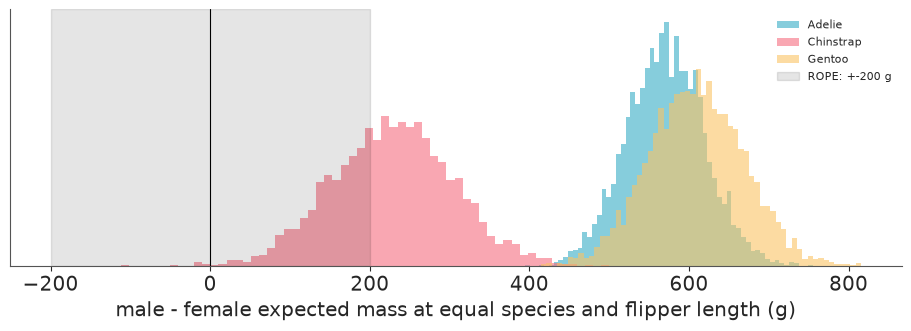

In [24]:
fig, ax = plt.subplots(figsize=(9, 3.2))
for k, sp in enumerate(species):
    draws = sex_diff.sel(species=sp).values.ravel()
    ax.hist(draws, bins=60, density=True, alpha=0.6, label=sp, color=f"C{k}")
ax.axvspan(*rope, color="k", alpha=0.1, label="ROPE: +-200 g")
ax.axvline(0, color="k", lw=0.8)
ax.set(xlabel="male - female expected mass at equal species and flipper length (g)", yticks=[])
ax.legend(fontsize=8);

For Adelie and Gentoo the whole interval is far outside the ROPE: sex belongs in the
reference. **Chinstrap is the instructive case.** Its interval excludes zero comfortably -
a significance test would report "a significant sex difference" and stop - but it straddles
200 g, so part of the interval is inside the ROPE and the honest answer to the *question
that was asked* is **undecided**: the data do not yet say whether the Chinstrap difference
is big enough to matter.

Why the ROPE is not a significance test in disguise:

- It has **three** outcomes, not two. It can *accept* practical equivalence (the whole
  interval inside), something a p-value can never do, and it can say "undecided" without
  that being read as "no effect".
- The reference is a **range on a meaningful scale**, stated before the analysis by someone
  who owns the decision - not the point value zero, which no one believes exactly and which
  any large dataset will reject.
- It is not a calculation on a sampling distribution: more data narrows the interval and
  moves you out of "undecided" *in either direction*.

Its weak point is the same as its strength: the answer depends on the ROPE, so report the
limits, who chose them, and (cheaply, from the same draws) how the conclusion changes for
other limits. `ci_in_rope` measures a share of the *interval*, which depends on `ci_prob`;
the last column, a plain posterior probability, does not.

In [25]:
limits = np.arange(50, 451, 50)
pd.DataFrame({sp: [(float((sex_diff.sel(species=sp) > t).mean())) for t in limits] for sp in species},
             index=pd.Index(limits, name="threshold (g)")).round(2).T

threshold (g),50,100,150,200,250,300,350,400,450
Adelie,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.99
Chinstrap,0.99,0.96,0.85,0.65,0.39,0.17,0.05,0.01,0.00
Gentoo,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


### 3.4 · Prior versus posterior: what did the data teach us?

A posterior that looks like its prior is a finding about the *data* (it was uninformative
for that quantity) and must be reported as such. `az.plot_prior_posterior` overlays the two;
the contraction $1 - \text{var}_\text{post}/\text{var}_\text{prior}$ puts a number on it.

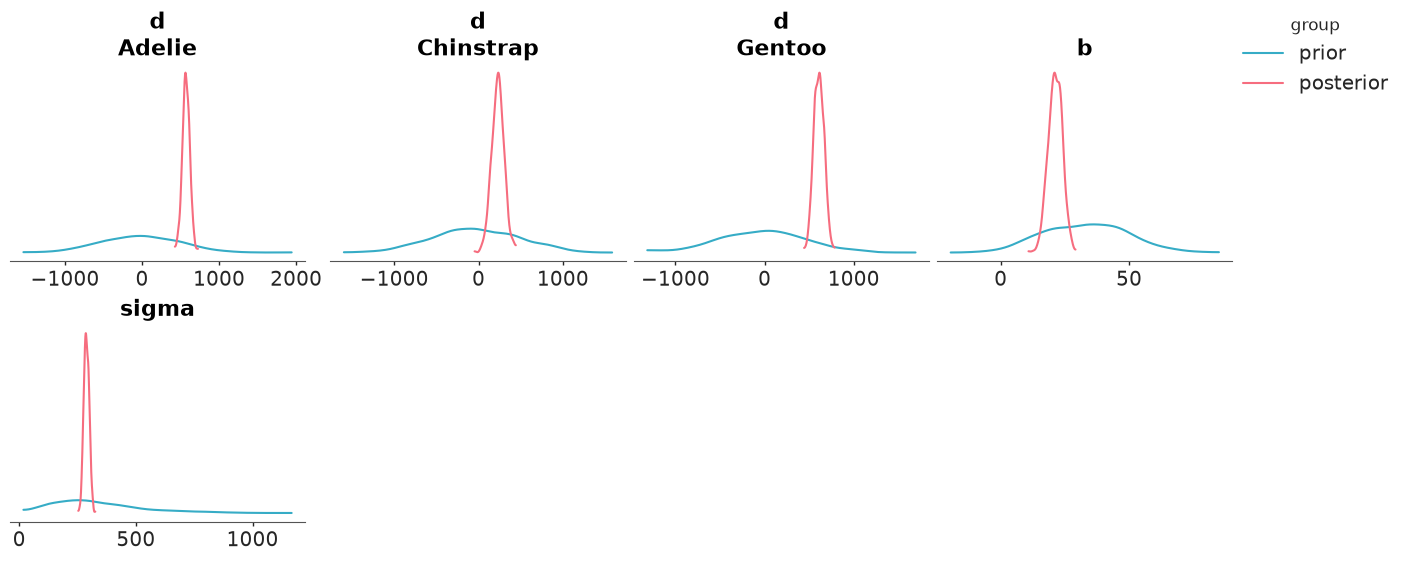

In [26]:
az.plot_prior_posterior(idata, var_names=["d", "b", "sigma"], figure_kwargs={"figsize": (14, 5.5)});

In [27]:
contraction = {}
for v in params:
    c = 1 - idata.posterior[v].var(("chain", "draw")) / idata.prior[v].var(("chain", "draw"))
    contraction[v] = np.atleast_1d(c.values).round(3)
    print(f"{v:>6}: contraction {contraction[v]}")

     a: contraction [0.997 0.996 0.997]
     d: contraction [0.99  0.978 0.986]
     b: contraction [0.973]
 sigma: contraction [0.997]


Every parameter's variance shrank by at least 97%: the conclusions are the data's, not the
prior's (Part 4 tests that claim from a second direction). The smallest contractions are for
the slope `b` - the parameter section 1.4 predicted would be hardest to learn - and for the
Chinstrap difference, which rests on 68 birds against 146 and 119. Note also where the
posterior for `b` sits: in the lower half of a prior whose upper end was "perfect geometric
scaling". The data agree with the reasoning that a flipper is a weak proxy for size.

### 3.5 · Variance explained

$R^2$ has a Bayesian version with a posterior: per draw, the variance of the fitted means
over that plus the residual variance (Gelman, Goodrich, Gabry & Vehtari 2019).
`az.bayesian_r2` wants the names of the mean and scale variables; `az.loo_r2` is the
leave-one-out version, which is the honest one when a model has many parameters.

In [28]:
r2_bayes = az.bayesian_r2(idata, pred_mean="expected", scale="sigma", ci_kind="hdi", ci_prob=0.94)
r2_loo = az.loo_r2(idata, var_name="mass", ci_kind="hdi", ci_prob=0.94)
within = penguins.groupby("species").mass.transform(lambda s: s - s.mean()).var() / penguins.mass.var()
print(r2_bayes, r2_loo, sep="\n")
print(f"share of the raw variance in body mass that is within species: {within:.2f}")

bayesian_R2(mean=0.87, hdi_lb=0.85, hdi_ub=0.89)
loo_R2(mean=0.87, hdi_lb=0.85, hdi_ub=0.89)
share of the raw variance in body mass that is within species: 0.33


The two agree, as they should for 8 parameters and 333 birds (a gap between them is a
symptom of overfitting). Report it with its context: most of that $R^2$ is "Gentoos are
big" - only a third of the variance in body mass is within species to begin with. A high
$R^2$ here says nothing about how well the model resolves the sex difference.

### 3.6 · Calibration - and what to write when it is not perfect

A density overlay (E01) cannot tell you whether the predictive **intervals** can be
trusted. The probability integral transform can: if the model is calibrated, the position
of each observation within its own predictive distribution is uniform. `az.plot_ppc_pit`
uses the posterior predictive; `az.plot_loo_pit` the leave-one-out predictive, so that each
bird is judged against a model that has not seen it. In ArviZ 1 both draw the difference
between the ECDF of the PIT values and that of a uniform (a flat line at zero is perfect
calibration), print the p-value of a uniformity test that remains valid for dependent PIT
values, and highlight the points responsible for any departure. (The older simultaneous
envelope, `method="envelope"`, raises a TypeError in ArviZ 1.3.)

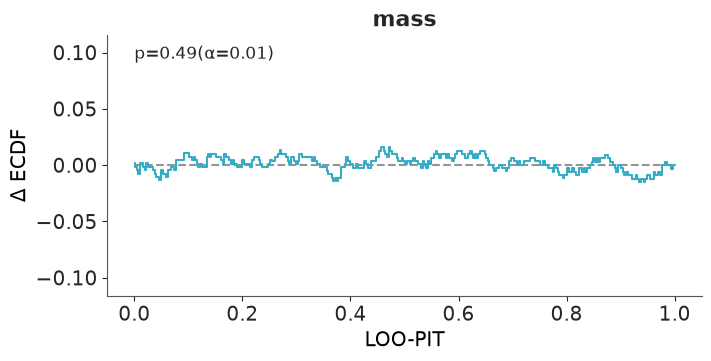

In [29]:
az.plot_loo_pit(idata, figure_kwargs={"figsize": (7, 3.5)});

The curve never strays more than about 0.02 from zero, no points are flagged and the test
finds nothing: taken over all birds, the predictive distribution is calibrated. A global
check can hide compensating errors in subgroups, and section 1.4's table hinted at one -
males looked more variable than females. So check the statistic the team's 5th-percentile
flag depends on, the **spread within each sex**:

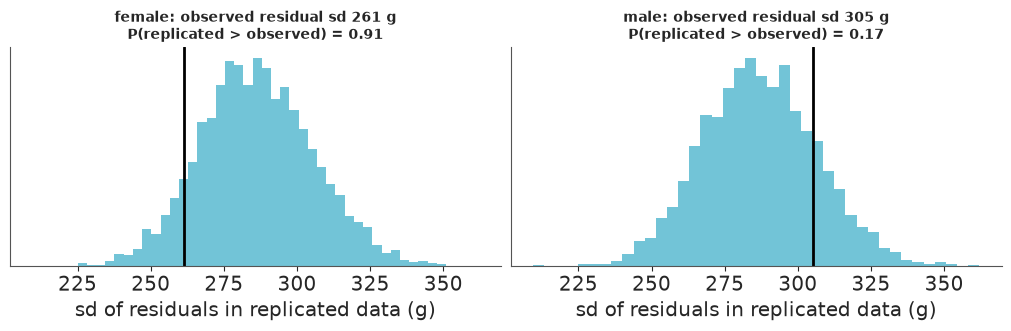

In [30]:
pp_resid = idata.posterior_predictive["mass"] - idata.posterior["expected"]
obs_resid = idata.observed_data["mass"] - idata.posterior["expected"].mean(("chain", "draw"))
sex_coord = ("obs", penguins.sex.to_numpy(dtype=object))
rep_sd = pp_resid.assign_coords(sex=sex_coord).groupby("sex").std()
obs_sd = obs_resid.assign_coords(sex=sex_coord).groupby("sex").std()
del pp_resid  # 4000 x 333 replicated residuals: reduced to two columns of sds above

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharex=True)
ppc_p = {}
for ax, sx in zip(axes, ["female", "male"]):
    rep = rep_sd.sel(sex=sx).values.ravel()
    ppc_p[sx] = float((rep > float(obs_sd.sel(sex=sx))).mean())
    ax.hist(rep, bins=40, alpha=0.7)
    ax.axvline(float(obs_sd.sel(sex=sx)), color="k", lw=2)
    ax.set(title=f"{sx}: observed residual sd {float(obs_sd.sel(sex=sx)):.0f} g\nP(replicated > observed) = {ppc_p[sx]:.2f}",
           xlabel="sd of residuals in replicated data (g)", yticks=[])
    ax.title.set_fontsize(10)

A lean rather than a failure: replicated females are more variable than the real ones in
about nine simulated datasets out of ten, replicated males less variable in about eight out
of ten. Neither tail probability would raise an eyebrow alone; together, in opposite
directions and agreeing with the raw table, they say a single $\sigma$ is a compromise. The
model is calibrated on average and slightly off for each sex - invisible in the global PIT.

What to **do**: the fix is one argument (`sigma_by_sex=True`), and Part 4 checks whether it
moves the headline. What to **write** if you keep the simpler model: say what was checked,
what it showed, in which direction, and what it touches. For example: *"Predictive checks
suggest the model overstates the spread of female masses and understates that of males
(residual sd about 260 g and 305 g against a common 288 g). This does not affect the
estimated sex differences (see sensitivity) but the individual reference ranges are
probably 5-10% too wide for females and too narrow for males."* A misfit you describe is a
limitation; a misfit you omit is an error.

## Part 4 · Robustness as part of the analysis

### 4.1 · Prior sensitivity by power-scaling

Refitting under every alternative prior is expensive; **power-scaling** (Kallioinen, Paananen,
Buerkner & Vehtari 2023) estimates the same thing from one fit. Raise the prior to a power
$\alpha$ slightly different from 1 (a slightly stronger or weaker prior), re-weight the
existing draws by importance sampling, and measure how far each marginal posterior moves;
then do the same to the likelihood. In ArviZ 1 that is `az.psense_summary`, and it needs
two groups in the tree: `log_likelihood` and `log_prior`. PyMC does not store either by
default - we added them in `fit()`.

| prior sensitivity | likelihood sensitivity | diagnosis |
|---|---|---|
| low | high | the data dominate - what you want |
| high | high | **prior-data conflict**: prior and likelihood both informative and pulling apart |
| high | low | **weak likelihood**: the posterior is mostly the prior |

In [31]:
psense_base = az.psense_summary(idata, var_names=params)
psense_base

,prior,likelihood,diagnosis
a[Adelie],0.042,0.105,✓
a[Chinstrap],0.029,0.118,✓
a[Gentoo],0.019,0.091,✓
d[Adelie],0.030,0.095,✓
d[Chinstrap],0.025,0.117,✓
d[Gentoo],0.040,0.116,✓
b,0.045,0.104,✓
sigma,0.002,0.121,✓


The numbers are sensitivities (how far the posterior moves, in a standardised distance, per
unit change of log2 $\alpha$); 0.05 is the conventional threshold. All prior sensitivities
are below it, all likelihood sensitivities above it: conclusions are driven by the data -
consistent with the contraction in 3.4.

### 4.2 · A refit under a prior someone might actually hold

A diagnostic that never fires teaches nothing, so give it something to find. Imagine a
reviewer who holds that "sex differences at equal structural size are small" and insists on
`d ~ Normal(0, 100)`. A manual refit shows what that prior does, and `psense_summary` shows
whether the diagnostic would have warned us.

In [32]:
sceptic_model = build_model(d_sigma=100.0)
idata_sceptic = fit(sceptic_model, log_prior=True)
sex_diff_sceptic = sex_difference(sceptic_model, idata_sceptic)
sceptic_shift = (sex_diff.mean(("chain", "draw")) - sex_diff_sceptic.mean(("chain", "draw"))).values
print(pd.DataFrame({"elicited prior": sex_diff.mean(("chain", "draw")).values,
                    "sceptical prior": sex_diff_sceptic.mean(("chain", "draw")).values,
                    "shift": -sceptic_shift}, index=species).round(0))
az.psense_summary(idata_sceptic, var_names=params)

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


           elicited prior  sceptical prior  shift
Adelie              570.0            444.0 -126.0
Chinstrap           229.0            127.0 -102.0
Gentoo              610.0            440.0 -169.0


,prior,likelihood,diagnosis
a[Adelie],0.318,0.375,potential prior-data conflict
a[Chinstrap],0.197,0.249,potential prior-data conflict
a[Gentoo],0.028,0.083,✓
d[Adelie],0.370,0.405,potential prior-data conflict
d[Chinstrap],0.193,0.232,potential prior-data conflict
d[Gentoo],0.429,0.448,potential prior-data conflict
b,0.270,0.277,potential prior-data conflict
sigma,0.169,0.306,potential prior-data conflict


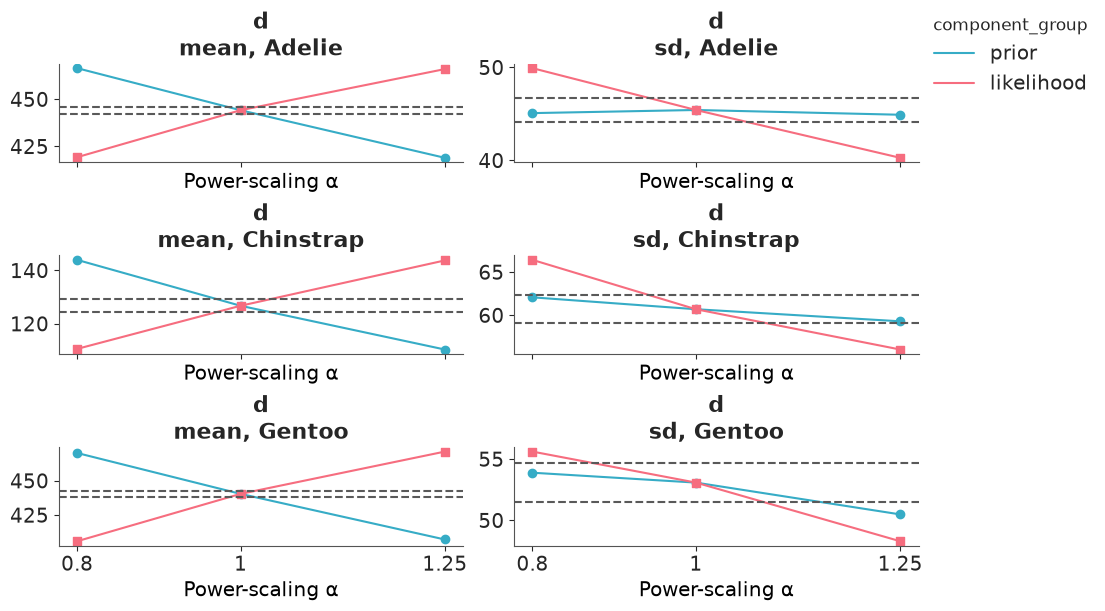

In [33]:
az.plot_psense_quantities(idata_sceptic, var_names=["d"], figure_kwargs={"figsize": (11, 6)});

The sceptical prior drags every sex difference down by 100-170 g, and power-scaling flags
it without being told: *prior-data conflict* on every `d` - and on most of the other
parameters too, because what a tight prior takes away from `d` has to be absorbed somewhere
(the slope picks up part of the sex difference along the ridge from 1.4).
`az.plot_psense_quantities` shows the mechanism: weaken the prior ($\alpha = 0.8$) and the
posterior mean rises by 20-30 g, strengthen it and it falls, while scaling the likelihood
does the opposite - an X far outside the dashed Monte Carlo error band. Under the elicited
prior the prior line is roughly a tenth as steep (compare the two sensitivity tables).
(`az.plot_psense_dist` draws the same comparison as densities; for a posterior this narrow
they are hard to read.)

A conflict flag does not say which side is wrong. Here the sceptic's prior puts the Adelie
difference the data favour (about 570 g) more than five prior standard deviations from
zero, against data from 146 birds; we keep the elicited prior and **report the comparison**
- a reader who shares the reviewer's view can see exactly what it would cost.

### 4.3 · Likelihood sensitivity, 4.4 · influential observations

The likelihood is an assumption too, and usually a less examined one than the prior. Three
alternatives to the Normal are defensible here: `StudentT` (robust to a few odd birds),
`LogNormal` (multiplicative biology; constant CV) and a Normal with a separate $\sigma$ per
sex (what 3.6 asked for). PSIS-LOO tells us two things at once: the Pareto $\hat{k}$ values
identify observations the posterior depends on heavily, and `az.compare` ranks the
likelihoods by out-of-sample predictive fit.

largest Pareto k: 0.26  (0 above 0.7)
       species     sex  flipper    mass  pareto_k  residual
329  Chinstrap  female    202.0  3400.0      0.26    -351.0
34      Adelie    male    184.0  4650.0      0.23     789.0
302  Chinstrap    male    210.0  4800.0      0.22     650.0


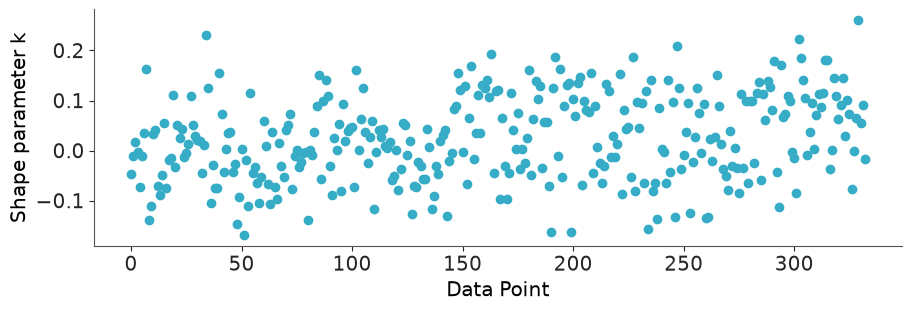

In [34]:
loo_base = az.loo(idata, pointwise=True)
k = loo_base.pareto_k.values
worst = penguins.iloc[np.argsort(k)[::-1][:3]][["species", "sex", "flipper", "mass"]].assign(
    pareto_k=np.sort(k)[::-1][:3].round(2),
    residual=lambda t: (t.mass - idata.posterior["expected"].mean(("chain", "draw")).values[t.index]).round(0))
print(f"largest Pareto k: {k.max():.2f}  ({(k > 0.7).sum()} above 0.7)")
print(worst)
az.plot_khat(loo_base, figure_kwargs={"figsize": (9, 3)});

No observation comes anywhere near 0.7, the value above which PSIS-LOO stops being
trustworthy: no single bird has leverage over this posterior, and LOO is reliable for the
comparison that follows. The three highest are simply the birds with the largest residuals
for their group. (When a $\hat{k}$ *is*
large, look the row up as we did here before doing anything else - it is usually a data
problem or a missing predictor, not a reason to delete the row. See E03 for LOO itself.)

### 4.5 · A small multiverse

The final robustness check generalises all of the above. List the analysis choices that a
reasonable colleague might have made differently (Steegen, Tuerlinckx, Gelman & Vanpaemel
2016 call the set of resulting analyses a *multiverse*), rerun, and tabulate **the headline
estimand** - not coefficients, which are not comparable across likelihoods. The
`sex_difference` function from 3.2 works unchanged for every model because each defines
`expected` on the gram scale.

In [35]:
specs = {
    "A · base: Normal, elicited priors": {},
    "B · all prior scales x10": {"prior_scale": 10.0},
    "C · sceptical prior d ~ N(0, 100)": {"d_sigma": 100.0},
    "D · StudentT likelihood": {"likelihood": "student"},
    "E · LogNormal likelihood": {"likelihood": "lognormal"},
    "F · sigma by sex": {"sigma_by_sex": True},
    "G · season (year) effects": {"year_effect": True},
    "H · no flipper: a DIFFERENT estimand": {"use_flipper": False},
}
def record(tree, sex_diff_draws, keep=()):
    """All we need from a fit: the estimand's draws, its LOO, two diagnostics, a few small parameters."""
    return {"sex_diff": sex_diff_draws, "loo": az.loo(tree, pointwise=True),
            "divergences": int(tree.sample_stats["diverging"].sum()),
            "rhat": float(az.rhat(tree, var_names=["d"])["d"].max()),
            "params": {v: tree.posterior[v].copy() for v in keep}}


keep_params = {"D · StudentT likelihood": ["nu"], "F · sigma by sex": ["sigma"],
               "E · LogNormal likelihood": ["a", "d", "sigma"]}
fits = {"A · base: Normal, elicited priors": record(idata, sex_diff),  # `idata` itself stays: the report reads it
        "C · sceptical prior d ~ N(0, 100)": record(idata_sceptic, sex_diff_sceptic)}
del idata_sceptic, sceptic_model  # a fitted tree is ~20-30 MB; the record is a few hundred KB
for label, kwargs in specs.items():
    if label not in fits:
        m = build_model(**kwargs)
        tree = fit(m)
        fits[label] = record(tree, sex_difference(m, tree), keep=keep_params.get(label, ()))
        del m, tree

rows = {}
for label in specs:
    sd_ = fits[label]["sex_diff"]
    row = {}
    for sp in species:
        x = sd_.sel(species=sp)
        lo, hi = az.hdi(x, prob=0.94).values
        row[sp] = f"{float(x.mean()):.0f} [{lo:.0f}, {hi:.0f}]"
    row["P(Chinstrap > 200)"] = round(float((sd_.sel(species="Chinstrap") > THRESHOLD).mean()), 2)
    row["divergences"] = fits[label]["divergences"]
    row["max r_hat"] = round(fits[label]["rhat"], 3)
    rows[label] = row
multiverse = pd.DataFrame(rows).T
multiverse

,Adelie,Chinstrap,Gentoo,P(Chinstrap > 200),divergences,max r_hat
"A · base: Normal, elicited priors","570 [479, 662]","229 [84, 366]","610 [499, 719]",0.65,0,1.002
B · all prior scales x10,"580 [488, 673]","243 [108, 378]","623 [510, 734]",0.72,0,1.002
"C · sceptical prior d ~ N(0, 100)","444 [356, 529]","127 [18, 244]","440 [341, 540]",0.11,0,1.001
D · StudentT likelihood,"568 [475, 658]","221 [82, 357]","607 [497, 717]",0.62,0,1.001
E · LogNormal likelihood,"576 [492, 659]","241 [112, 363]","568 [429, 699]",0.74,0,1.002
F · sigma by sex,"570 [477, 663]","234 [100, 374]","614 [505, 715]",0.68,0,1.001
G · season (year) effects,"561 [471, 657]","214 [83, 352]","592 [483, 702]",0.58,42,1.001
H · no flipper: a DIFFERENT estimand,"665 [566, 761]","401 [264, 534]","796 [686, 898]",1.0,0,1.002


In [36]:
comparison = az.compare({label.split(" · ")[1]: fits[label]["loo"] for label in specs if label[0] in "ADEFG"}, round_to=1)
comparison[["rank", "elpd", "p", "elpd_diff", "dse", "weight"]]

,rank,elpd,p,elpd_diff,dse,weight
season (year) effects,0,-2360.5,9.5,0.0,0.0,0.5
sigma by sex,1,-2360.8,8.4,-0.3,2.8,0.5
"base: Normal, elicited priors",2,-2362.0,7.6,-1.5,2.1,0.0
StudentT likelihood,3,-2362.7,7.7,-2.3,2.1,0.0
LogNormal likelihood,4,-2370.2,7.9,-9.7,5.0,0.0


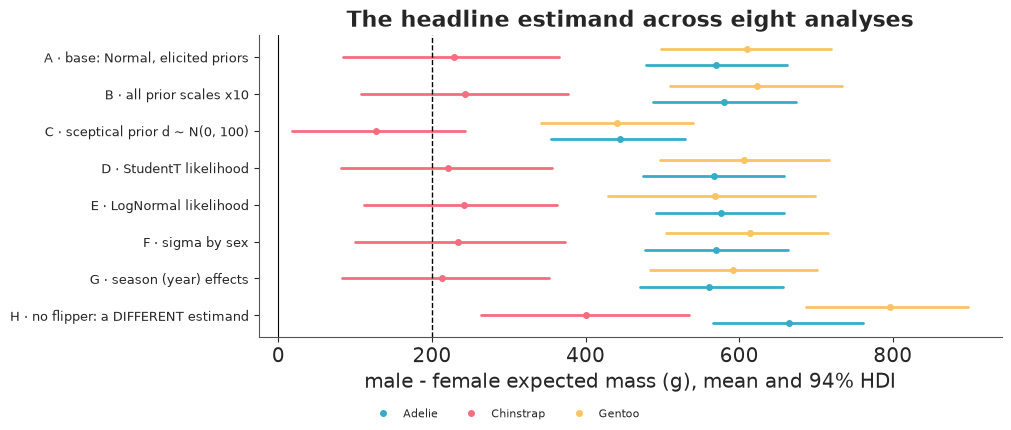

In [37]:
fig, ax = plt.subplots(figsize=(10, 4.2))
labels = list(specs)
for j, label in enumerate(labels):
    for k_, sp in enumerate(species):
        x = fits[label]["sex_diff"].sel(species=sp)
        lo, hi = az.hdi(x, prob=0.94).values
        y = len(labels) - j + (k_ - 1) * 0.22
        ax.plot([lo, hi], [y, y], color=f"C{k_}", lw=2)
        ax.plot(float(x.mean()), y, "o", color=f"C{k_}", ms=4, label=sp if j == 0 else None)
ax.axvline(THRESHOLD, color="k", ls="--", lw=1)
ax.axvline(0, color="k", lw=0.8)
ax.set_yticks(range(len(labels), 0, -1), labels, fontsize=9)
ax.set(xlabel="male - female expected mass (g), mean and 94% HDI", title="The headline estimand across eight analyses")
fig.legend(fontsize=8, loc="outside lower center", ncol=3);

In [38]:
nu_post = fits["D · StudentT likelihood"]["params"]["nu"]
sig_f = fits["F · sigma by sex"]["params"]["sigma"]
print(f"StudentT nu: posterior mean {float(nu_post.mean()):.0f}, 94% HDI {az.hdi(nu_post, prob=0.94).values.round(0)}")
print(f"sigma by sex: female {float(sig_f.sel(sex='female').mean()):.0f} g, male {float(sig_f.sel(sex='male').mean()):.0f} g, "
      f"P(male > female) = {float((sig_f.sel(sex='male') > sig_f.sel(sex='female')).mean()):.3f}")
defensible = [l for l in specs if l[0] in "ABDEFG"]
spread = {sp: (min(float(fits[l]["sex_diff"].sel(species=sp).mean()) for l in defensible),
               max(float(fits[l]["sex_diff"].sel(species=sp).mean()) for l in defensible)) for sp in species}
p_chin = (multiverse.loc[defensible, "P(Chinstrap > 200)"].min(), multiverse.loc[defensible, "P(Chinstrap > 200)"].max())
print("range of posterior means across the defensible analyses (A, B, D-G):",
      {sp: tuple(round(v) for v in r) for sp, r in spread.items()})
print("range of P(Chinstrap > 200 g):", p_chin)

StudentT nu: posterior mean 30, 94% HDI [ 8. 57.]
sigma by sex: female 266 g, male 310 g, P(male > female) = 0.975
range of posterior means across the defensible analyses (A, B, D-G): {'Adelie': (561, 580), 'Chinstrap': (214, 243), 'Gentoo': (568, 623)}
range of P(Chinstrap > 200 g): (0.58, 0.74)


How to read the table:

- **A, B, D, E, F, G** are choices a careful analyst could defend. Across them the posterior
  means move by 20-60 g - well inside any single interval - and the qualitative conclusions
  never change: Adelie and Gentoo far above 200 g, Chinstrap straddling it with a
  probability somewhere between about 0.6 and 0.75. That stability is the robustness result, and
  it goes in the report as a sentence.
- LOO separates the likelihoods less than you might hope: season effects, sex-specific
  $\sigma$, the base model and the StudentT are within 2 elpd units of each other, with
  standard errors of 2-3 - indistinguishable. The StudentT's $\nu$ sits above its prior mean
  of 20: the data see no heavy tails. The separate-$\sigma$ model does confirm that males are
  more variable, without moving the sex differences; if the deliverable were the *reference
  ranges* rather than the sex difference, F would be the model to ship.
- The one model LOO does reject is the **LogNormal** (about 10 elpd behind, two standard
  errors) - the mean-variance plot in 1.2 said so before any model was fitted. It is also the
  variant whose Gentoo estimate differs most: lower, and with a wider interval, since a
  constant CV gives the heaviest species the largest spread.
- **C** is in the table to show the cost of a prior we rejected for stated reasons (4.2).
- **H is not a robustness check.** Dropping flipper length changes the question from
  "heavier at the same size" to "heavier", and the answer moves by 100-190 g - as much as the
  prior we rejected, and far more than any defensible variant. A multiverse is only meaningful across analyses that target the
  **same estimand**; when a specification changes the estimand, the right reaction is to go
  back to the brief, not to average.

## Part 5 · The report

Everything a stakeholder reads should be regenerated from the fit, so the text cannot drift
from the numbers. The cell below builds the report with f-strings from the variables
computed above; the next cell is its rendered output, written for the field team - no
Greek letters until the appendix.

In [39]:
def fmt(x, digits=0):
    return f"{x:,.{digits}f}"


e = estimands
chin_p = e.loc["Chinstrap", f"P(> {THRESHOLD:.0f} g)"]
sd_f, sd_m = float(obs_sd.sel(sex="female")), float(obs_sd.sel(sex="male"))
scen = scenarios.set_index(["species", "sex"])
p_chin_100, p_chin_300 = (float((sex_diff.sel(species="Chinstrap") > t).mean()) for t in (100, 300))

report = f"""
### Does a body-mass reference for Palmer penguins need to know the bird's sex?

**Question.** At the same species and flipper length, do males and females differ in expected
body mass by more than {THRESHOLD:.0f} g - the difference the field team said would change how
they judge a bird's condition?

**Answer.** Yes for Adelie and Gentoo, **not settled** for Chinstrap.

| Species | Male minus female, same flipper length | 94% credible interval | Probability the difference exceeds {THRESHOLD:.0f} g |
|---|---|---|---|
| Adelie | {fmt(e.loc['Adelie', 'mean'])} g | {fmt(e.loc['Adelie', 'lo'])} to {fmt(e.loc['Adelie', 'hi'])} g | {e.loc['Adelie', f'P(> {THRESHOLD:.0f} g)']:.2f} |
| Chinstrap | {fmt(e.loc['Chinstrap', 'mean'])} g | {fmt(e.loc['Chinstrap', 'lo'])} to {fmt(e.loc['Chinstrap', 'hi'])} g | {chin_p:.2f} |
| Gentoo | {fmt(e.loc['Gentoo', 'mean'])} g | {fmt(e.loc['Gentoo', 'lo'])} to {fmt(e.loc['Gentoo', 'hi'])} g | {e.loc['Gentoo', f'P(> {THRESHOLD:.0f} g)']:.2f} |

For Adelie and Gentoo a single reference line would be wrong by roughly +-300 g depending on
the bird's sex. For Chinstrap the difference is clearly above zero, but whether it exceeds the
{THRESHOLD:.0f} g that matters is open: the probability is {chin_p:.2f}, nearer a coin flip than a
conclusion. It is very probably more than 100 g (probability {p_chin_100:.2f}) and probably not
more than 300 g ({p_chin_300:.2f}); only {int((penguins.species == 'Chinstrap').sum())} Chinstraps were measured. These are statements about
**average** birds. Individuals overlap: the chance that a randomly chosen male outweighs a
randomly chosen female of the same species and flipper length is
{float(p_male_heavier.sel(species='Adelie').mean()):.0%} (Adelie),
{float(p_male_heavier.sel(species='Chinstrap').mean()):.0%} (Chinstrap) and
{float(p_male_heavier.sel(species='Gentoo').mean()):.0%} (Gentoo), so mass alone cannot sex a bird.

**Reference values.** A female Adelie with a {scen.loc[('Adelie', 'female'), 'flipper']} mm flipper is
expected to weigh {fmt(scen.loc[('Adelie', 'female'), 'expected mass'])} g (94% interval for that
average: {fmt(scen.loc[('Adelie', 'female'), 'mean lo'])}-{fmt(scen.loc[('Adelie', 'female'), 'mean hi'])} g);
94% of individual birds of that kind fall between {fmt(scen.loc[('Adelie', 'female'), 'bird lo'])} and
{fmt(scen.loc[('Adelie', 'female'), 'bird hi'])} g, and 1 in 20 falls below
{fmt(scen.loc[('Adelie', 'female'), '5th percentile'])} g. The full table is in section 3.2. Each extra 10 mm of
flipper adds {fmt(float(plus10.mean()))} g (94% interval {fmt(az.hdi(plus10, prob=0.94).values[0])}-{fmt(az.hdi(plus10, prob=0.94).values[1])} g).

**Data and exclusions.** {len(penguins_all)} field records from Palmer Station LTER (Gorman, Williams &
Fraser 2014), seasons {years.min()}-{years.max()}. Excluded: {int(no_measure.sum())} records with no measurements and
{int(no_sex.sum())} birds whose sex could not be determined (no blood sample, or the sexing assay failed), leaving
{len(penguins)}. The exclusions are few and tied to laboratory problems rather than to the birds'
mass, but this was not tested.

**Model, in words.** Body mass is described as a species- and sex-specific average, plus a
common increase per millimetre of flipper length, plus bird-to-bird variation that follows a
bell curve with the same spread for all birds.

**Priors.** Set from general knowledge before looking at the masses: group averages between
2.7 and 6.3 kg; a sex difference within +-1000 g with no preferred sign; a flipper slope
between 0 and 65 g/mm (the upper end is what perfect geometric scaling would give); individual
variation of a few hundred grams. Simulating from these priors gave plausible penguins
({float(((idata.prior_predictive['mass'] < 1000) | (idata.prior_predictive['mass'] > 10_000)).mean()):.1%} of simulated birds outside 1-10 kg).

**Computation.** PyMC {pm.__version__} with the nutpie NUTS sampler: {diag['chains']} chains of {diag['draws']:,} draws after
{diag['tune']} warm-up steps; {diag['div']} divergent transitions, largest R-hat {diag['rhat']:.2f}, smallest effective
sample size {diag['ess']:,}.

**Checks.** Leave-one-out predictive calibration (LOO-PIT) shows no departure from uniformity; no
influential observations (largest Pareto k {k.max():.2f}). The model explains {r2_loo.mean:.0%} of the variance in
body mass out of sample, most of it differences between species. One misfit: males vary more
than females (residual sd {fmt(sd_m)} g vs {fmt(sd_f)} g), so the ranges for individual birds above are probably
5-10% too wide for females and too narrow for males. The sex differences are unaffected (next paragraph).

**Sensitivity.** Across six defensible variants - priors ten times wider, heavy-tailed or
multiplicative errors, sex-specific spread, season effects - the estimated differences stay within
{fmt(spread['Adelie'][0])}-{fmt(spread['Adelie'][1])} g (Adelie), {fmt(spread['Chinstrap'][0])}-{fmt(spread['Chinstrap'][1])} g (Chinstrap) and
{fmt(spread['Gentoo'][0])}-{fmt(spread['Gentoo'][1])} g (Gentoo), and the Chinstrap probability between {p_chin[0]:.2f} and {p_chin[1]:.2f}.
A model with multiplicative errors predicts clearly worse than the others; the rest are indistinguishable.
Power-scaling finds no prior sensitivity. A deliberately sceptical prior (differences expected to be
within +-200 g) lowers the estimates by {fmt(sceptic_shift.min())}-{fmt(sceptic_shift.max())} g and is flagged as conflicting with the data.

**Limitations.** Observational data from three islands and three seasons; each species-sex
average rests on {int(penguins.groupby(['species', 'sex']).size().min())}-{int(penguins.groupby(['species', 'sex']).size().max())} birds. Records are treated as independent
although birds were sampled as nesting pairs. Mass varies within a season (birds were weighed at
the egg stage), so the reference values apply to that stage only. "Same flipper length" is a
proxy for "same structural size". A bird of unknown sex cannot be compared with a sex-specific
reference; for such a bird the male and female reference values bracket what to expect.

**Recommendation.** Use sex-specific references for Adelie and Gentoo. For Chinstrap the estimate sits
so close to the {THRESHOLD:.0f} g threshold that a moderately larger sample would not settle the question either
(the interval is {fmt(e.loc['Chinstrap', 'hi'] - e.loc['Chinstrap', 'lo'])} g wide; it would have to shrink several-fold). Decide on cost instead: a
sex-blind Chinstrap reference would misjudge a bird by about +-{fmt(e.loc['Chinstrap', 'mean'] / 2)} g (half the difference),
against about +-300 g for the other two species.
"""
Markdown(report)


### Does a body-mass reference for Palmer penguins need to know the bird's sex?

**Question.** At the same species and flipper length, do males and females differ in expected
body mass by more than 200 g - the difference the field team said would change how
they judge a bird's condition?

**Answer.** Yes for Adelie and Gentoo, **not settled** for Chinstrap.

| Species | Male minus female, same flipper length | 94% credible interval | Probability the difference exceeds 200 g |
|---|---|---|---|
| Adelie | 570 g | 479 to 662 g | 1.00 |
| Chinstrap | 229 g | 84 to 366 g | 0.65 |
| Gentoo | 610 g | 499 to 719 g | 1.00 |

For Adelie and Gentoo a single reference line would be wrong by roughly +-300 g depending on
the bird's sex. For Chinstrap the difference is clearly above zero, but whether it exceeds the
200 g that matters is open: the probability is 0.65, nearer a coin flip than a
conclusion. It is very probably more than 100 g (probability 0.96) and probably not
more than 300 g (0.17); only 68 Chinstraps were measured. These are statements about
**average** birds. Individuals overlap: the chance that a randomly chosen male outweighs a
randomly chosen female of the same species and flipper length is
92% (Adelie),
71% (Chinstrap) and
93% (Gentoo), so mass alone cannot sex a bird.

**Reference values.** A female Adelie with a 188 mm flipper is
expected to weigh 3,376 g (94% interval for that
average: 3,314-3,439 g);
94% of individual birds of that kind fall between 2,824 and
3,929 g, and 1 in 20 falls below
2,899 g. The full table is in section 3.2. Each extra 10 mm of
flipper adds 213 g (94% interval 162-265 g).

**Data and exclusions.** 344 field records from Palmer Station LTER (Gorman, Williams &
Fraser 2014), seasons 2007-2009. Excluded: 2 records with no measurements and
9 birds whose sex could not be determined (no blood sample, or the sexing assay failed), leaving
333. The exclusions are few and tied to laboratory problems rather than to the birds'
mass, but this was not tested.

**Model, in words.** Body mass is described as a species- and sex-specific average, plus a
common increase per millimetre of flipper length, plus bird-to-bird variation that follows a
bell curve with the same spread for all birds.

**Priors.** Set from general knowledge before looking at the masses: group averages between
2.7 and 6.3 kg; a sex difference within +-1000 g with no preferred sign; a flipper slope
between 0 and 65 g/mm (the upper end is what perfect geometric scaling would give); individual
variation of a few hundred grams. Simulating from these priors gave plausible penguins
(0.1% of simulated birds outside 1-10 kg).

**Computation.** PyMC 6.3.2 with the nutpie NUTS sampler: 4 chains of 1,000 draws after
400 warm-up steps; 0 divergent transitions, largest R-hat 1.00, smallest effective
sample size 1,475.

**Checks.** Leave-one-out predictive calibration (LOO-PIT) shows no departure from uniformity; no
influential observations (largest Pareto k 0.26). The model explains 87% of the variance in
body mass out of sample, most of it differences between species. One misfit: males vary more
than females (residual sd 305 g vs 261 g), so the ranges for individual birds above are probably
5-10% too wide for females and too narrow for males. The sex differences are unaffected (next paragraph).

**Sensitivity.** Across six defensible variants - priors ten times wider, heavy-tailed or
multiplicative errors, sex-specific spread, season effects - the estimated differences stay within
561-580 g (Adelie), 214-243 g (Chinstrap) and
568-623 g (Gentoo), and the Chinstrap probability between 0.58 and 0.74.
A model with multiplicative errors predicts clearly worse than the others; the rest are indistinguishable.
Power-scaling finds no prior sensitivity. A deliberately sceptical prior (differences expected to be
within +-200 g) lowers the estimates by 102-169 g and is flagged as conflicting with the data.

**Limitations.** Observational data from three islands and three seasons; each species-sex
average rests on 34-73 birds. Records are treated as independent
although birds were sampled as nesting pairs. Mass varies within a season (birds were weighed at
the egg stage), so the reference values apply to that stage only. "Same flipper length" is a
proxy for "same structural size". A bird of unknown sex cannot be compared with a sex-specific
reference; for such a bird the male and female reference values bracket what to expect.

**Recommendation.** Use sex-specific references for Adelie and Gentoo. For Chinstrap the estimate sits
so close to the 200 g threshold that a moderately larger sample would not settle the question either
(the interval is 282 g wide; it would have to shrink several-fold). Decide on cost instead: a
sex-blind Chinstrap reference would misjudge a bird by about +-114 g (half the difference),
against about +-300 g for the other two species.


**Appendix for the statistical reader** (also part of the report):

$$
\begin{aligned}
\text{mass}_i &\sim \text{Normal}(\mu_i, \sigma), \qquad
\mu_i = a_{s[i]} + d_{s[i]}\,\text{male}_i + b\,(\text{flipper}_i - 200) \\
a_s &\sim \text{Normal}(4500, 918), \quad d_s \sim \text{Normal}(0, 510), \quad
b \sim \text{Normal}(32.5, 16.6), \quad \sigma \sim \text{Gamma}(\text{mean } 341, \text{sd } 196)
\end{aligned}
$$

Estimand: $\frac{1}{n_s}\sum_{i \in s} E[\text{mass} \mid \text{male}, x_i] - E[\text{mass} \mid
\text{female}, x_i]$, summarised by posterior mean and 94% highest-density interval. The
prior parameters are the PreliZ maximum-entropy solutions printed in section 2.1; the
footer below is generated by code.

In [40]:
def reproducibility_footer():
    import platform

    import nutpie
    import xarray

    attrs = idata.posterior.attrs
    lines = [f"- run: {pd.Timestamp.now():%Y-%m-%d}, Python {sys.version.split()[0]}, {platform.platform()}",
             "- packages: " + ", ".join(f"{m.__name__} {m.__version__}" for m in (pm, az, pz, nutpie, np, pd, xarray)),
             f"- sampler: NUTS ({attrs['inference_library']} {attrs['inference_library_version']}), {diag['chains']} chains x {diag['draws']} draws "
             f"after {diag['tune']} warm-up steps; random_seed = {RANDOM_SEED} in every sampling call",
             f"- data: `penguins_raw` - {data.REGISTRY['penguins_raw'].source}",
             f"  {data.REGISTRY['penguins_raw'].url}",
             f"- rows used: {len(penguins)} of {len(penguins_all)}; source notebook: notebook_src/examples/D03_exploratory_analysis_and_reporting.py"]
    return "\n".join(lines)


print(reproducibility_footer())

- run: 2026-09-19, Python 3.12.8, macOS-26.5.1-arm64-arm-64bit
- packages: pymc 6.3.2, arviz 1.3.0, preliz 0.28.0, nutpie 0.16.11, numpy 2.5.3, pandas 3.0.6, xarray 2026.7.0
- sampler: NUTS (nutpie 0.16.11), 4 chains x 1000 draws after 400 warm-up steps; random_seed = 42 in every sampling call
- data: `penguins_raw` - Gorman, Williams & Fraser (2014), Palmer Station LTER, via R `palmerpenguins` (raw field records).
  https://vincentarelbundock.github.io/Rdatasets/csv/palmerpenguins/penguins_raw.csv
- rows used: 333 of 344; source notebook: notebook_src/examples/D03_exploratory_analysis_and_reporting.py


### A checklist for a Bayesian analysis report

In the spirit of Kruschke's *Bayesian Analysis Reporting Guidelines* (BARG; Nature Human
Behaviour, 2021), the WAMBS checklist (Depaoli & van de Schoot, Psychological Methods, 2017)
and the workflow paper of Gelman et al. (2020, arXiv:2011.01808):

1. **Question and estimand** - in the stakeholder's words and units, including any
   threshold or ROPE and who set it, *before* the results.
2. **Data** - source, collection, every exclusion with counts and reasons, how missing
   values were handled.
3. **Model** - likelihood and why (the EDA that motivated it), structure in words and in
   math, software and versions.
4. **Priors** - every one, with its justification, and a prior predictive check. "Weakly
   informative" is not a justification; a range on a meaningful scale is.
5. **Computation** - sampler, chains, draws, seed; R-hat, ESS, divergences - one or two
   sentences unless something went wrong, in which case say what and what you did.
6. **Model checks** - posterior predictive checks aimed at the quantities the conclusions
   depend on, calibration, influential observations; **report the misfits**.
7. **Results** - estimands on the outcome scale with a stated interval type and probability
   (e.g. "94% HDI"), probabilities of the events the decision depends on, and the
   distinction between uncertainty about an average and the spread of individuals.
8. **Sensitivity** - priors (power-scaling and at least one refit), likelihood, and other
   defensible analysis choices; say what changed and what did not.
9. **Limitations** and the population the conclusions apply to.
10. **Reproducibility** - code, data, versions, seed; ideally the posterior draws.

### Wording mistakes that reviewers (rightly) jump on

| Do not write | Why | Write instead |
|---|---|---|
| "the 94% **confidence** interval is [84, 366]" | a confidence interval is a statement about a procedure over repeated samples; this is a statement about the parameter given the data and the model | "94% credible interval (HDI)"; say which kind (HDI or equal-tailed) and which probability |
| "there is a 94% chance the true value is in [84, 366]" - with no conditions | true only *given the model and priors* | "given the model and priors, the probability is 94% that ..." (once, early, is enough) |
| "the interval includes zero, so there is **no effect**" | absence of evidence; the interval may also include large effects | report the interval and P(effect > threshold), or a ROPE decision including "undecided" |
| "the interval excludes zero, so the effect is **significant**" | imports a test you did not run and ignores size (Chinstrap above) | "the difference is almost certainly positive (probability above 0.99); whether it exceeds 200 g is uncertain (0.65)" |
| "the probability of the hypothesis is 0.97" for $P(d > 0)$ | it is the posterior probability of a *direction* under this model, not of a scientific hypothesis | "posterior probability that the difference is positive" |
| "the model is confirmed by the posterior predictive check" | a check can fail to find a problem; it cannot validate | "the checks we ran found no misfit in ..., and did find ..." |
| "the prior was uninformative" | no prior is; flat priors on one scale are informative on another (2.3) | state the prior, the prior predictive result and the sensitivity result |
| reporting $\exp(\text{mean of } \beta)$ as "the mean effect", or back-transforming interval *means* | the mean does not commute with non-linear transforms: $E[g(\theta)] \neq g(E[\theta])$ | transform **each draw**, then summarise (quantiles and HDIs of monotone transforms are safe for quantiles only) |
| "the expected mass is 3,400 g [2,850, 3,950]" | which interval - for the mean, or for a bird? | label every interval: "for the average" vs "for an individual" |

The non-linear-transform row is easy to demonstrate with model E, whose coefficients live on
the log scale:

In [41]:
pe = fits["E · LogNormal likelihood"]["params"]  # the three small arrays kept from model E
a_E, d_E, s_E = (pe[v].sel(species="Gentoo") if "species" in pe[v].dims else pe[v] for v in ("a", "d", "sigma"))
wrong = np.exp(float(a_E.mean()) + float(d_E.mean())) - np.exp(float(a_E.mean()))
right = (np.exp(a_E + d_E + s_E**2 / 2) - np.exp(a_E + s_E**2 / 2)).mean()
print("Gentoo male - female at 200 mm, LogNormal model")
print(f"  plugging posterior means into exp():        {wrong:.1f} g   <- a difference of MEDIANS at the mean parameters")
print(f"  transforming every draw, then averaging:    {float(right):.1f} g   <- difference of expected masses")
print(f"  'males are exp(mean d) = {np.exp(float(d_E.mean())):.4f} times heavier' vs mean of exp(d) = {float(np.exp(d_E).mean()):.4f}")

Gentoo male - female at 200 mm, LogNormal model
  plugging posterior means into exp():        517.9 g   <- a difference of MEDIANS at the mean parameters
  transforming every draw, then averaging:    519.6 g   <- difference of expected masses
  'males are exp(mean d) = 1.1184 times heavier' vs mean of exp(d) = 1.1185


With a CV of 7% and a tight posterior the two differ by less than 2 g here. The gap grows
with $\sigma$ and with posterior uncertainty - in a count model with a log link and sparse
data it can be tens of percent - and doing it correctly costs nothing, so always transform
draws.

### Try it yourself

1. **Change the estimand.** The team now asks "how much heavier are males, full stop?"
   Answer it from the *base* model (not model H) by averaging `expected` over the males and
   over the females of each species with their own flipper lengths. Compare with model H and
   with the raw differences. What extra uncertainty does this estimand carry that the
   conditional one does not?
2. **Make the prior matter.** Refit the base model on a random 10% of the birds. Rerun the
   contraction table, `az.psense_summary` and the x10-prior row of the multiverse. Which
   conclusions are now prior-dependent, and how would you write that in the report?
3. **EDA on a dataset of your choice.** Take `wells` (binary outcome) or `seatbelts`
   (monthly counts), produce the Part 1 plots that apply (support, mean-variance, groups,
   collinearity, residual structure) and write the one-sentence modelling decision under
   each. For `wells`, check your decisions against E03.

Next: **D01** for cleaning the raw file properly, **E03** for model comparison, or
challenge **C09** for an analysis where the estimand is causal.